# Te damos la bienvenida a Colab

## 1. Introducción
En los últimos años, plataformas como Airbnb han dejado de ser exclusivamente un espacio para que particulares arrienden sus hogares de forma ocasional. Hoy, una fracción significativa de los anuncios en Europa corresponde a operadores comerciales, agencias inmobiliarias y empresas de gestión vacacional, que operan decenas o cientos de propiedades bajo perfiles de "anfitriones particulares", evadiendo normativas turísticas y distorsionando el mercado de arriendo residencial.

Este fenómeno, conocido como **turistificación**, tiene consecuencias directas sobre el acceso a vivienda en ciudades como Barcelona, Lisboa o París: reduce la oferta de arriendo residencial, infla los precios y transforma barrios enteros en zonas de uso turístico intensivo.

Este proyecto busca abordar este problema desde la minería de datos, utilizando el dataset **Airbnb Market Data Europe** (~95.000 anuncios, 61 variables) complementado con datos históricos mensuales de ocupación y precios (`past_rates`, ~1.1M registros). Juntos, estos datasets permiten analizar no solo el estado actual del mercado, sino también su comportamiento estacional.

El análisis se estructura en torno a cuatro preguntas de investigación que combinan técnicas supervisadas y no supervisadas, y que buscan entregar herramientas concretas para reguladores y organismos de política pública.

## **2 Exploración de Datos**

Esta sección cubre la carga, auditoría, limpieza e integración de los datos. El objetivo es llegar a un dataset único y limpio (`df_full`) que sirva de base para todos los modelos.

## 2.1 Carga del Dataset
Cargamos el dataset principal desde el repositorio del proyecto. Usamos el formato `.parquet` en vez del `.csv` original, ya que este último presentaba errores de parseo que corrompían varias columnas.

In [1]:
!pip -q install pyarrow


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
pd.set_option('future.no_silent_downcasting', True)

url = "https://raw.githubusercontent.com/Rajevic-0/Proyecto-Mineria-De-Datos/21614a18231f34a2f38d2e238fca764d134ef4a2/listings.parquet"

try:
    df_init = pd.read_parquet(url, engine="pyarrow")
    print(f"Carga exitosa — {df_init.shape[0]:,} registros × {df_init.shape[1]} columnas")
except Exception as e:
    print(f"Error: {e}")

df_init.head(3)

/tmp/ipykernel_16380/3279759580.py:9: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


Carga exitosa — 95,898 registros × 61 columnas


,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city
0,121902,Entire home,entire_home,https://a0.muscache.com/im/pictures/77c0e3a9-0...,77,fe453949b595,false,37.0758,27.2426,6,...,0.0,0.0,0.0,0,90,90,90,Turkey,Muğla,Bodrum
1,805342,Entire condo,entire_home,https://a0.muscache.com/im/pictures/11494599/4...,16,59711ec4c245,false,37.0092,27.2563,3,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum
2,805361,Entire home,entire_home,https://a0.muscache.com/im/pictures/bda48dbc-d...,34,d217bf6e3427,false,37.0292,27.4410,5,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum


## 2.2 Auditoría Inicial

Antes de cualquier limpieza, auditamos el dataset para entender su estructura: tipos de datos, presencia de nulos y duplicados.

In [3]:
df_init.describe()

,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city
count,95898,95329,95329,95102,95102,95329,95322,95327,95273,84865,...,95329,95329,95329,95329,95329,95329,94854,95898,95898,95898
unique,95882,129,485,94429,689,68528,473,55034,63476,24,...,6114,2670,4254,94,93,92,5,36,136,373
top,"⭐⭐⭐⭐⭐""",Entire rental unit,entire_home,18,16,ad1c8827240f,false,40.6318,4,4,...,0.0,0.0,0.0,0,0,90,90,France,England,Alanya
freq,6,47104,81709,19,3103,81,52890,28,142,26729,...,37224,71407,71044,37136,56248,37331,94850,25253,8650,308


In [4]:
print("AUDITORÍA INICIAL")
print("="*55)
print(f"Registros : {df_init.shape[0]:,}")
print(f"Columnas  : {df_init.shape[1]}")
print(f"\n--- Tipos de columnas ---")
print(df_init.dtypes.value_counts())

# Nulos
nulls_pct = (df_init.isnull().mean() * 100).round(2)
null_report = nulls_pct[nulls_pct > 0].sort_values(ascending=False)
print(f"\n--- Columnas con valores nulos ({len(null_report)} columnas) ---")
print(null_report.to_string())
print(f"\nFilas duplicadas: {df_init.duplicated().sum():,}")

# Valores únicos en categóricas clave
print("\n--- Valores únicos en columnas categóricas ---")
for col in ['room_type', 'professional_management', 'cancellation_policy', 'superhost']:
    unique_vals = df_init[col].value_counts()
    print(f"\n  {col} ({df_init[col].nunique()} valores únicos):")
    print(f"  {unique_vals.head(8).to_string()}")
    if len(unique_vals) > 8:
        print(f"  ... y {len(unique_vals) - 8} valores más")

AUDITORÍA INICIAL
Registros : 95,898
Columnas  : 61

--- Tipos de columnas ---
str    61
Name: count, dtype: int64

--- Columnas con valores nulos (57 columnas) ---
instant_book                   79.44
bedrooms                       18.06
guests                         11.50
professional_management        11.29
extra_guest_fee                 4.01
rating_accuracy                 3.32
rating_checkin                  3.32
rating_overall                  3.32
rating_cleanliness              3.32
rating_communication            3.32
rating_location                 3.32
rating_value                    3.31
cleaning_fee                    2.68
min_nights                      1.76
beds                            1.63
l90d_total_days                 1.09
amenities                       0.98
baths                           0.94
registration                    0.87
cover_photo_url                 0.83
photos_count                    0.83
num_reviews                     0.69
longitude            

La auditoría revela tres problemas a resolver en la limpieza:

Valores nulos: instant_book (79%) es inutilizable. bedrooms y guests (~11-18%) tienen nulos pero son variables relevantes — se imputan. El resto de columnas tiene nulos menores al 5%.

Valores inválidos en categóricas: varias columnas muestran un número anómalo de valores únicos, producto de errores de parseo del CSV original:

* room_type: 485 valores únicos cuando los válidos son 4 — las filas corruptas contienen URLs de fotos.
* professional_management: mezcla true/false con números y strings de amenities.
    cancellation_policy: contiene el valor "EUR" (pertenece a currency).
    superhost: contiene coordenadas geográficas en vez de true/false.

Columnas redundantes: las versiones *_native de métricas financieras duplican información ya disponible en USD.


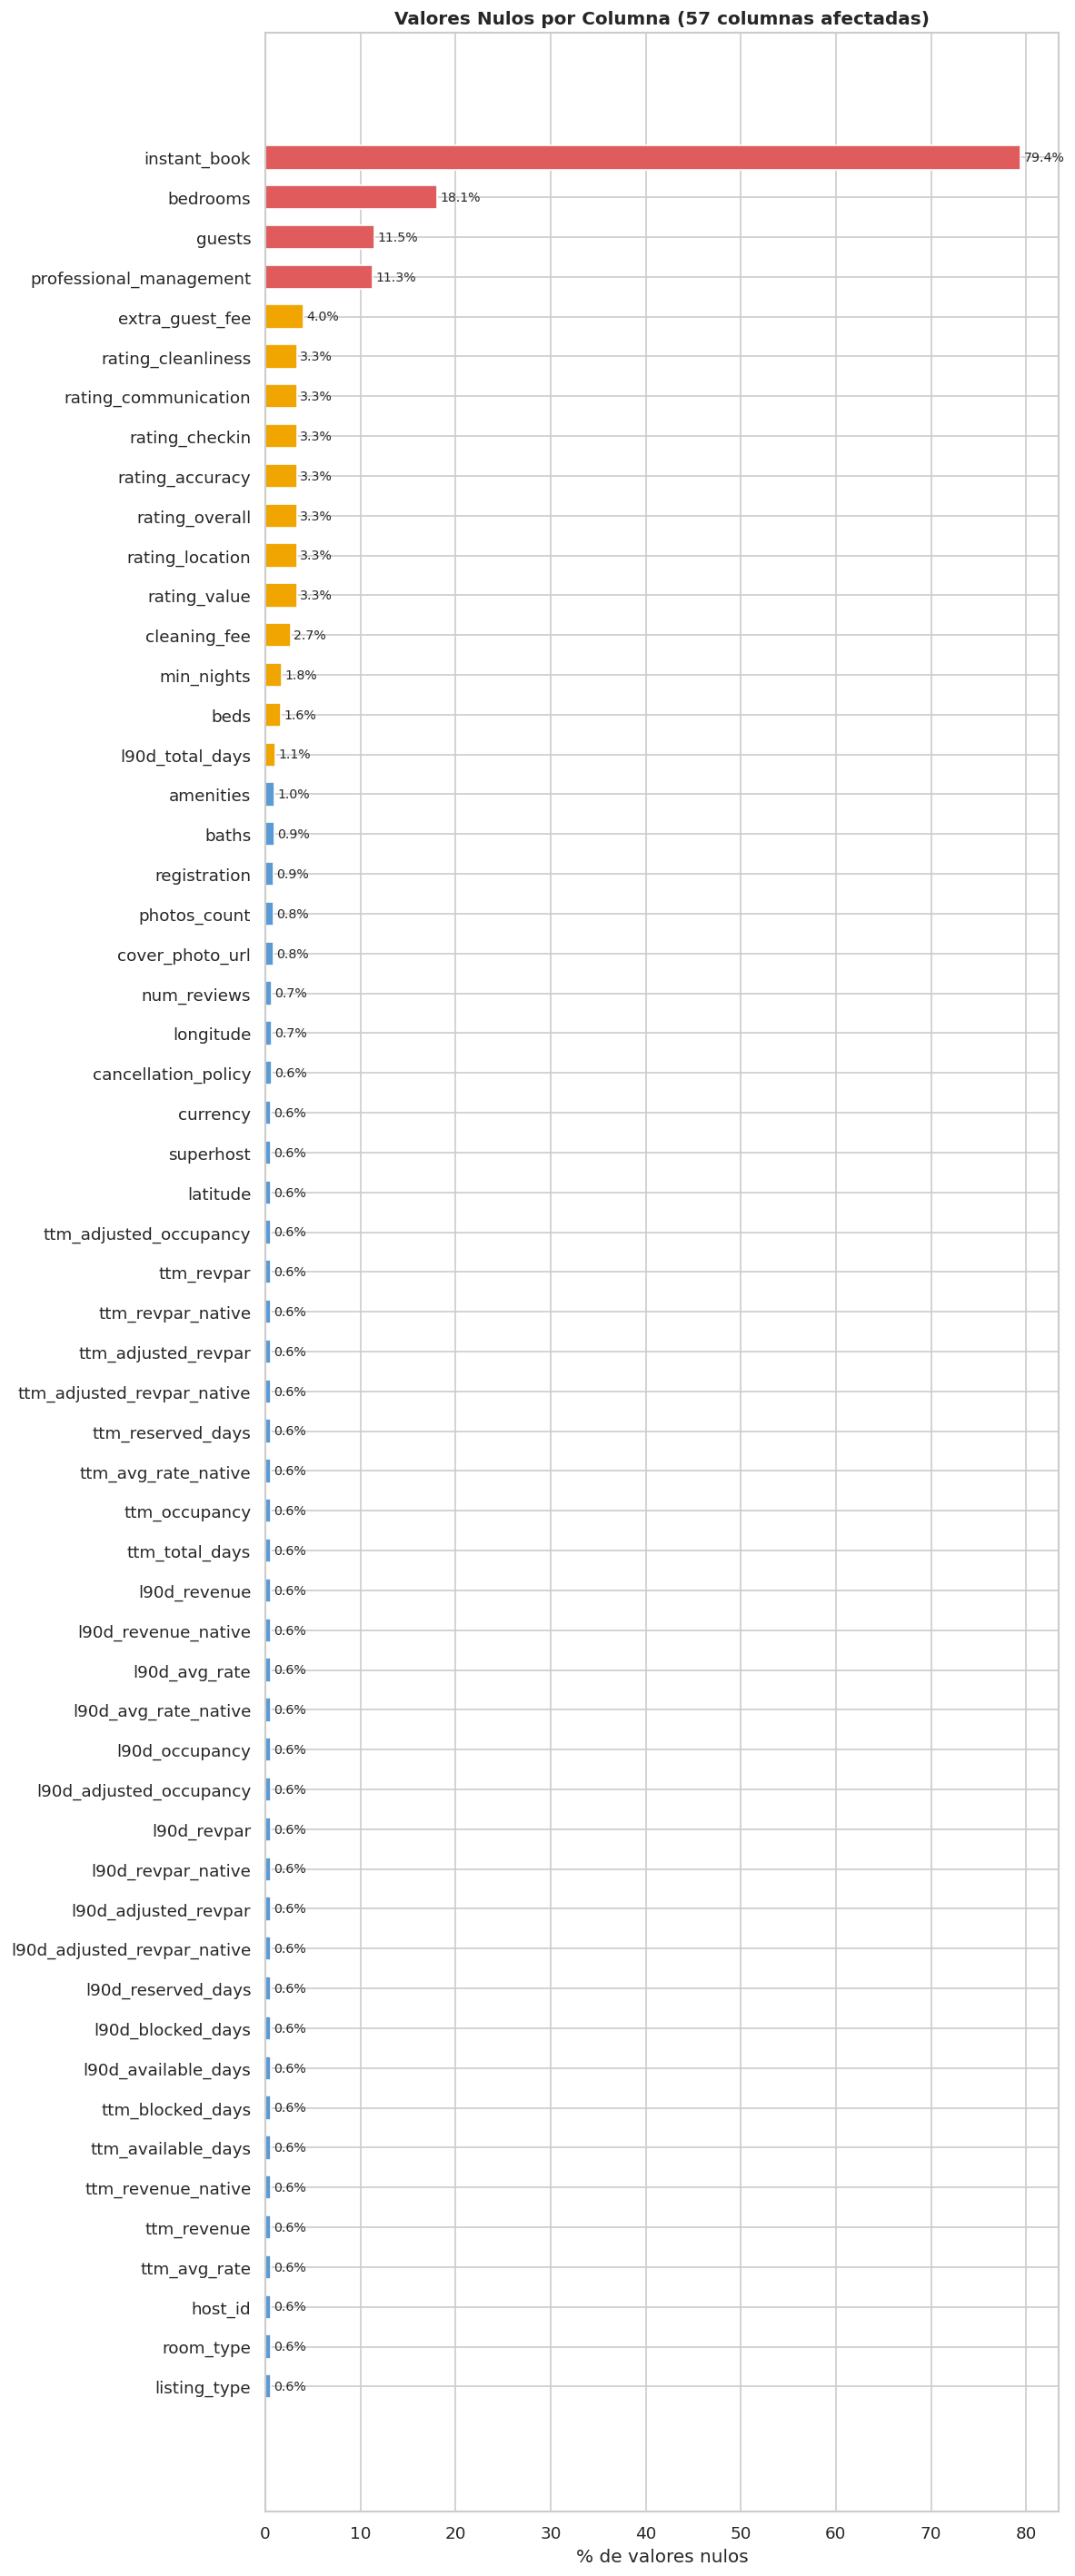

In [5]:
nulls_pct = (df_init.isnull().mean() * 100).round(2)
null_report = nulls_pct[nulls_pct > 0].sort_values()

fig, ax = plt.subplots(figsize=(10, len(null_report) * 0.4 + 1))
colors = ["#e05c5c" if v > 10 else "#f0a500" if v > 1 else "#5b9bd5" for v in null_report]
bars = ax.barh(null_report.index, null_report, color=colors, edgecolor="white", height=0.6)

for bar, val in zip(bars, null_report):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8.5)

ax.set_xlabel("% de valores nulos")
ax.set_title(f"Valores Nulos por Columna ({len(null_report)} columnas afectadas)", fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 Limpieza del Dataset
La limpieza sigue un orden específico para evitar sesgos:
1. **Duplicados** - primero, para no sesgar las métricas de imputación.
2. **Filas corruptas** - filtrar por valores válidos conocidos en las columnas afectadas.
3. **Columnas irrelevantes** - eliminar antes de imputar para no procesar lo que se va a descartar.
4. **Imputación** - solo en columnas que usaremos en los modelos.

In [6]:
df = df_init.copy()

# PASO 1: Duplicados
before = len(df)
df = df.drop_duplicates()
print(f"PASO 1 - Duplicados eliminados: {before - len(df):,} | Quedan: {len(df):,}")

# PASO 2: Filas corruptas
before = len(df)
df = df[
    df['room_type'].isin(['entire_home', 'private_room', 'hotel_room', 'shared_room']) &
    df['professional_management'].isin(['true', 'false']) &
    df['superhost'].isin(['true', 'false']) &
    ~df['cancellation_policy'].isin(['EUR'])
].copy()
print(f"PASO 2 - Filas corruptas eliminadas: {before - len(df):,} | Quedan: {len(df):,}")

# Convertir booleanos
df['professional_management'] = df['professional_management'].map({'true': 1, 'false': 0})
df['superhost']               = df['superhost'].map({'true': 1, 'false': 0})

vc = df['professional_management'].value_counts()
print(f"\nBalance professional_management:")
print(f"  Particulares  (0): {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)")
print(f"  Profesionales (1): {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)")

PASO 1 - Duplicados eliminados: 2 | Quedan: 95,896
PASO 2 - Filas corruptas eliminadas: 11,293 | Quedan: 84,603

Balance professional_management:
  Particulares  (0): 80,465 (95.1%)
  Profesionales (1): 4,138 (4.9%)


In [7]:
# PASO 3: Eliminar columnas irrelevantes
cols_to_drop = [
    'instant_book', 'cover_photo_url', 'registration', 'amenities', 'currency',
    'ttm_revenue_native', 'ttm_avg_rate_native', 'ttm_revpar_native',
    'ttm_adjusted_revpar_native', 'l90d_revenue_native', 'l90d_avg_rate_native',
    'l90d_revpar_native', 'l90d_adjusted_revpar_native',
]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f"PASO 3 - Columnas eliminadas: {len(cols_to_drop)} | Restantes: {df.shape[1]}")

PASO 3 - Columnas eliminadas: 13 | Restantes: 48


In [8]:
# PASO 4: Imputación de nulos
# Coordenadas: eliminar filas (no imputar ubicaciones falsas)
before = len(df)
df = df.dropna(subset=['latitude', 'longitude'])
print(f"Filas sin coordenadas eliminadas: {before - len(df):,}")

# Numéricas: mediana
cols_mediana = [
    'bedrooms', 'guests', 'min_nights', 'cleaning_fee', 'extra_guest_fee',
    'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin',
    'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value',
    'beds', 'baths', 'photos_count',
    'ttm_revenue', 'ttm_avg_rate', 'ttm_occupancy', 'ttm_adjusted_occupancy',
    'ttm_revpar', 'ttm_adjusted_revpar', 'ttm_reserved_days', 'ttm_blocked_days',
    'ttm_available_days', 'ttm_total_days', 'l90d_revenue', 'l90d_avg_rate',
    'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_adjusted_revpar',
    'l90d_reserved_days', 'l90d_blocked_days', 'l90d_available_days', 'l90d_total_days',
]
print("\nImputación con mediana:")
for col in cols_mediana:
    if col in df.columns and df[col].isna().sum() > 0:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        n = df[col].isna().sum()
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  {col:42s} mediana={median_val:.2f}  (imputados: {n:,})")

# Categóricas: moda
for col in ['cancellation_policy', 'host_id', 'state']:
    if col in df.columns and df[col].isna().sum() > 0:
        mode_val = df[col].mode().iloc[0]
        n = df[col].isna().sum()
        df[col] = df[col].fillna(mode_val)
        print(f"  {col:42s} moda='{mode_val}'  (imputados: {n:,})")

remaining = df.isnull().sum().sum()
print(f"\nNulos restantes: {remaining if remaining > 0 else 'Ninguno'}")
df_clean = df.copy()
print(f"Dataset limpio: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")

Filas sin coordenadas eliminadas: 0

Imputación con mediana:
  bedrooms                                   mediana=2.00  (imputados: 15,174)
  guests                                     mediana=4.00  (imputados: 9,504)
  min_nights                                 mediana=2.00  (imputados: 930)
  cleaning_fee                               mediana=23.00  (imputados: 1,941)
  extra_guest_fee                            mediana=0.00  (imputados: 1,978)
  num_reviews                                mediana=67.00  (imputados: 69)
  rating_overall                             mediana=4.82  (imputados: 2,309)
  rating_accuracy                            mediana=4.90  (imputados: 2,309)
  rating_checkin                             mediana=4.90  (imputados: 2,309)
  rating_cleanliness                         mediana=4.80  (imputados: 2,309)
  rating_communication                       mediana=4.90  (imputados: 2,309)
  rating_location                            mediana=4.80  (imputados: 2,309)
  rat

### 2.4 Integración de Datos Históricos
El dataset incluye un segundo archivo (`past_rates`) con registros mensuales de ocupación, ingresos y precios para cada anuncio, cubriendo aproximadamente 12 meses. Esto nos permite calcular features de comportamiento temporal que no están disponibles en el snapshot estático de `listings`.
Verificamos primero la cobertura del join antes de integrarlo.

In [9]:
url_rates = "https://raw.githubusercontent.com/Rajevic-0/Proyecto-Mineria-De-Datos/21614a18231f34a2f38d2e238fca764d134ef4a2/past_rates.parquet"
df_rates = pd.read_parquet(url_rates, engine="pyarrow")
print(f"past_rates: {df_rates.shape[0]:,} registros × {df_rates.shape[1]} columnas")
print(f"Rango de fechas: {df_rates['date'].min()} — {df_rates['date'].max()}")

# Verificar cobertura del join
ids_listings = set(df_clean['listing_id'].astype(str))
ids_rates    = set(df_rates['listing_id'].astype(str))
print(f"\nCobertura del join:")
print(f"  Anuncios en listings : {len(ids_listings):,}")
print(f"  Anuncios en rates    : {len(ids_rates):,}")
print(f"  En común             : {len(ids_listings & ids_rates):,}  ({len(ids_listings & ids_rates)/len(ids_listings)*100:.1f}% de listings)")

past_rates: 1,115,174 registros × 17 columnas
Rango de fechas: 2025-02-01 — 2026-01-01

Cobertura del join:
  Anuncios en listings : 84,603
  Anuncios en rates    : 95,162
  En común             : 84,422  (99.8% de listings)


El join cubre el 99.8% de los anuncios — prácticamente todo el dataset. Los 181 anuncios sin historial se imputan con la mediana al momento del join. A partir de los registros mensuales calculamos features agregadas por anuncio que capturan su comportamiento a lo largo del año.

In [10]:
# Calcular features por anuncio
cols_rates = ['listing_id', 'date', 'occupancy', 'revenue',
              'rate_avg', 'booking_lead_time_avg', 'length_of_stay_avg']
df_rates_clean = df_rates[cols_rates].copy()
for c in cols_rates[2:]:
    df_rates_clean[c] = pd.to_numeric(df_rates_clean[c], errors='coerce')

features_rates = df_rates_clean.groupby('listing_id').agg(
    occ_media       = ('occupancy',             'mean'),  # ocupación promedio
    occ_std         = ('occupancy',             'std'),   # variabilidad estacional
    occ_max         = ('occupancy',             'max'),   # pico temporada alta
    revenue_total   = ('revenue',               'sum'),   # ingresos totales anuales
    rate_media      = ('rate_avg',              'mean'),  # precio promedio real
    rate_std        = ('rate_avg',              'std'),   # variabilidad de precio
    lead_time_media = ('booking_lead_time_avg', 'mean'),  # anticipación de reservas
    estadia_media   = ('length_of_stay_avg',    'mean'),  # duración promedio estadía
    n_meses         = ('date',                  'count'), # meses con actividad
).reset_index()

# Join
df_clean['listing_id']       = df_clean['listing_id'].astype(str)
features_rates['listing_id'] = features_rates['listing_id'].astype(str)
df_full = df_clean.merge(features_rates, on='listing_id', how='left')

# Imputar los 181 sin historial
for col in ['occ_media', 'occ_std', 'occ_max', 'revenue_total',
            'rate_media', 'rate_std', 'lead_time_media', 'estadia_media', 'n_meses']:
    df_full[col] = df_full[col].fillna(df_full[col].median())

print(f"df_full: {df_full.shape[0]:,} filas × {df_full.shape[1]} columnas")
print(f"Nulos tras join: {df_full.isnull().sum().sum()}")

df_full: 84,603 filas × 57 columnas
Nulos tras join: 0


### 2.5 Análisis Estadístico Descriptivo
Con el dataset integrado, analizamos la distribución de las variables clave y su varianza. El **coeficiente de variación (CV)** nos indica qué variables tienen suficiente dispersión para ser útiles en los modelos — a mayor CV, más señal.

In [11]:
num_vars = [
    'rate_media', 'occ_media', 'occ_std', 'revenue_total',
    'rate_std', 'lead_time_media', 'estadia_media',
    'guests', 'bedrooms', 'num_reviews', 'rating_overall',
    'professional_management']
num_vars = [c for c in num_vars if c in df_full.columns]
for c in num_vars:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')

print("Estadísticas descriptivas:")
print("="*55)
print(df_full[num_vars].describe().round(2).to_string())

print("\nCoeficiente de Variación (mayor CV = más señal):")
print("="*55)
cv = (df_full[num_vars].std() / df_full[num_vars].mean() * 100).sort_values(ascending=False)
for col, val in cv.items():
    print(f"  {col:30s} CV={val:.1f}%")

Estadísticas descriptivas:
       rate_media  occ_media   occ_std  revenue_total  rate_std  lead_time_media  estadia_media    guests  bedrooms  num_reviews  rating_overall  professional_management
count    84603.00   84603.00  84603.00       84603.00  84603.00         84603.00       84603.00  84603.00  84603.00     84603.00        84603.00                 84603.00
mean       160.97       0.34      0.26       19055.52     25.91            65.96           7.54      4.35      1.93       121.17            4.77                     0.05
std        166.38       0.22      0.10       23227.96     45.67            47.66           9.37      2.25      1.08       150.77            0.20                     0.22
min          9.97       0.00      0.00           0.00      0.08             1.00           1.00      1.00      0.00         1.00            2.00                     0.00
25%         79.25       0.15      0.17        5993.50      6.67            30.25           3.38      3.00      1.00        

### 2.6 Distribución Geográfica y por Tipo de Alojamiento
Exploramos cómo se distribuyen precio y ocupación entre países y tipos de alojamiento. Esto tiene dos objetivos: validar que existe varianza geográfica real (que justifique `country` como feature en los modelos) y anticipar patrones para el clustering de P1.

Nos enfocamos en los 10 países con más anuncios, que representan la mayoría del dataset.

/tmp/ipykernel_16380/3413830544.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full, x='room_type', y='rate_media',


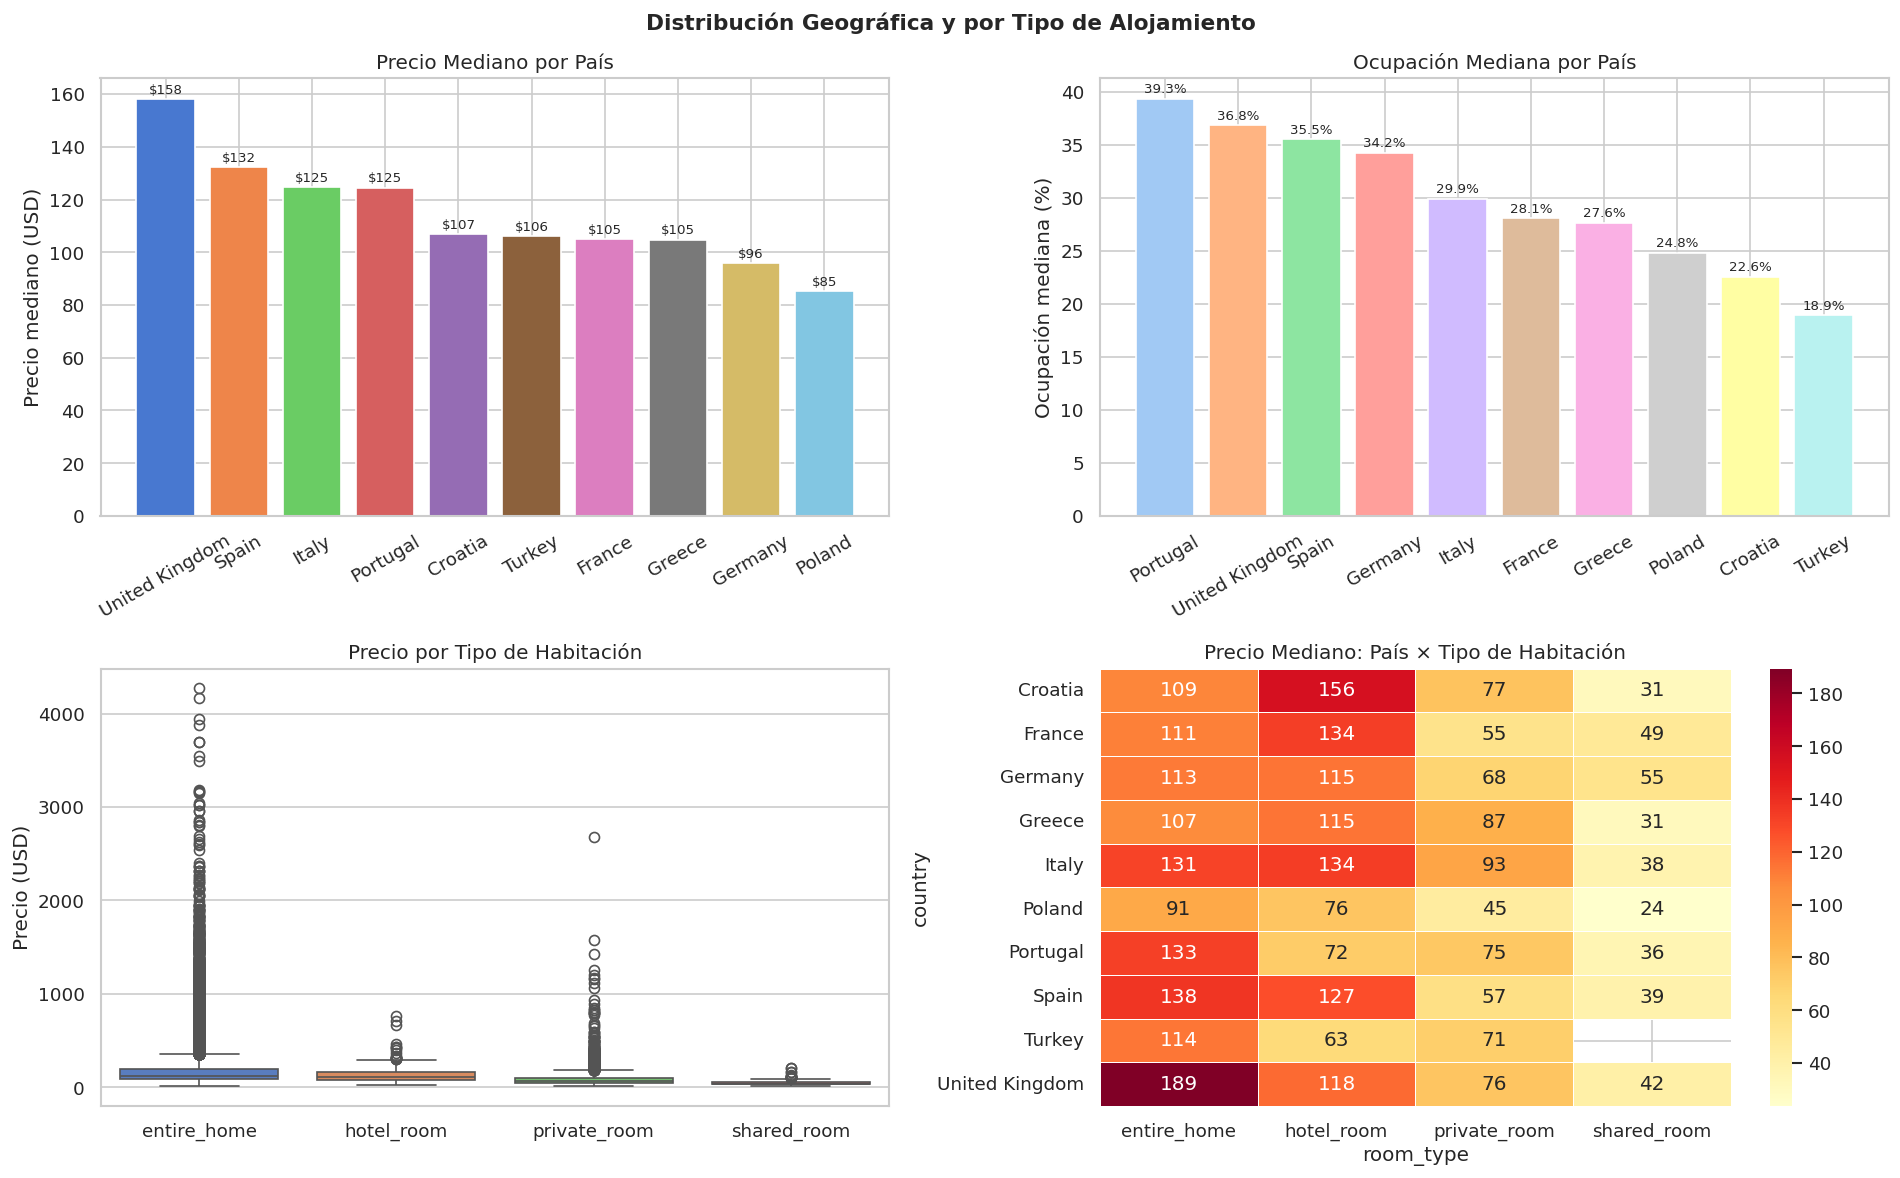

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
top_countries = df_full['country'].value_counts().head(10).index

# 1. Precio mediano por país
country_price = (df_full[df_full['country'].isin(top_countries)]
    .groupby('country')['rate_media'].median()
    .sort_values(ascending=False).reset_index())
axes[0, 0].bar(country_price['country'], country_price['rate_media'],
               color=sns.color_palette('muted', len(country_price)))
axes[0, 0].set_title('Precio Mediano por País')
axes[0, 0].set_ylabel('Precio mediano (USD)')
axes[0, 0].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0, 0].patches, country_price['rate_media']):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'${val:.0f}', ha='center', va='bottom', fontsize=8)

# 2. Ocupación mediana por país
country_occ = (df_full[df_full['country'].isin(top_countries)]
    .groupby('country')['occ_media'].median()
    .sort_values(ascending=False).reset_index())
axes[0, 1].bar(country_occ['country'], country_occ['occ_media'] * 100,
               color=sns.color_palette('pastel', len(country_occ)))
axes[0, 1].set_title('Ocupación Mediana por País')
axes[0, 1].set_ylabel('Ocupación mediana (%)')
axes[0, 1].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0, 1].patches, country_occ['occ_media']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)

# 3. Boxplot precio por room_type
order_rt = df_full.groupby('room_type')['rate_media'].median().sort_values(ascending=False).index
sns.boxplot(data=df_full, x='room_type', y='rate_media',
            order=order_rt, palette='muted', ax=axes[1, 0])
axes[1, 0].set_title('Precio por Tipo de Habitación')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Precio (USD)')

# 4. Heatmap precio mediano país × room_type
pivot = df_full[df_full['country'].isin(top_countries)].pivot_table(
    values='rate_media', index='country', columns='room_type', aggfunc='median')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Precio Mediano: País × Tipo de Habitación')

plt.suptitle('Distribución Geográfica y por Tipo de Alojamiento',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


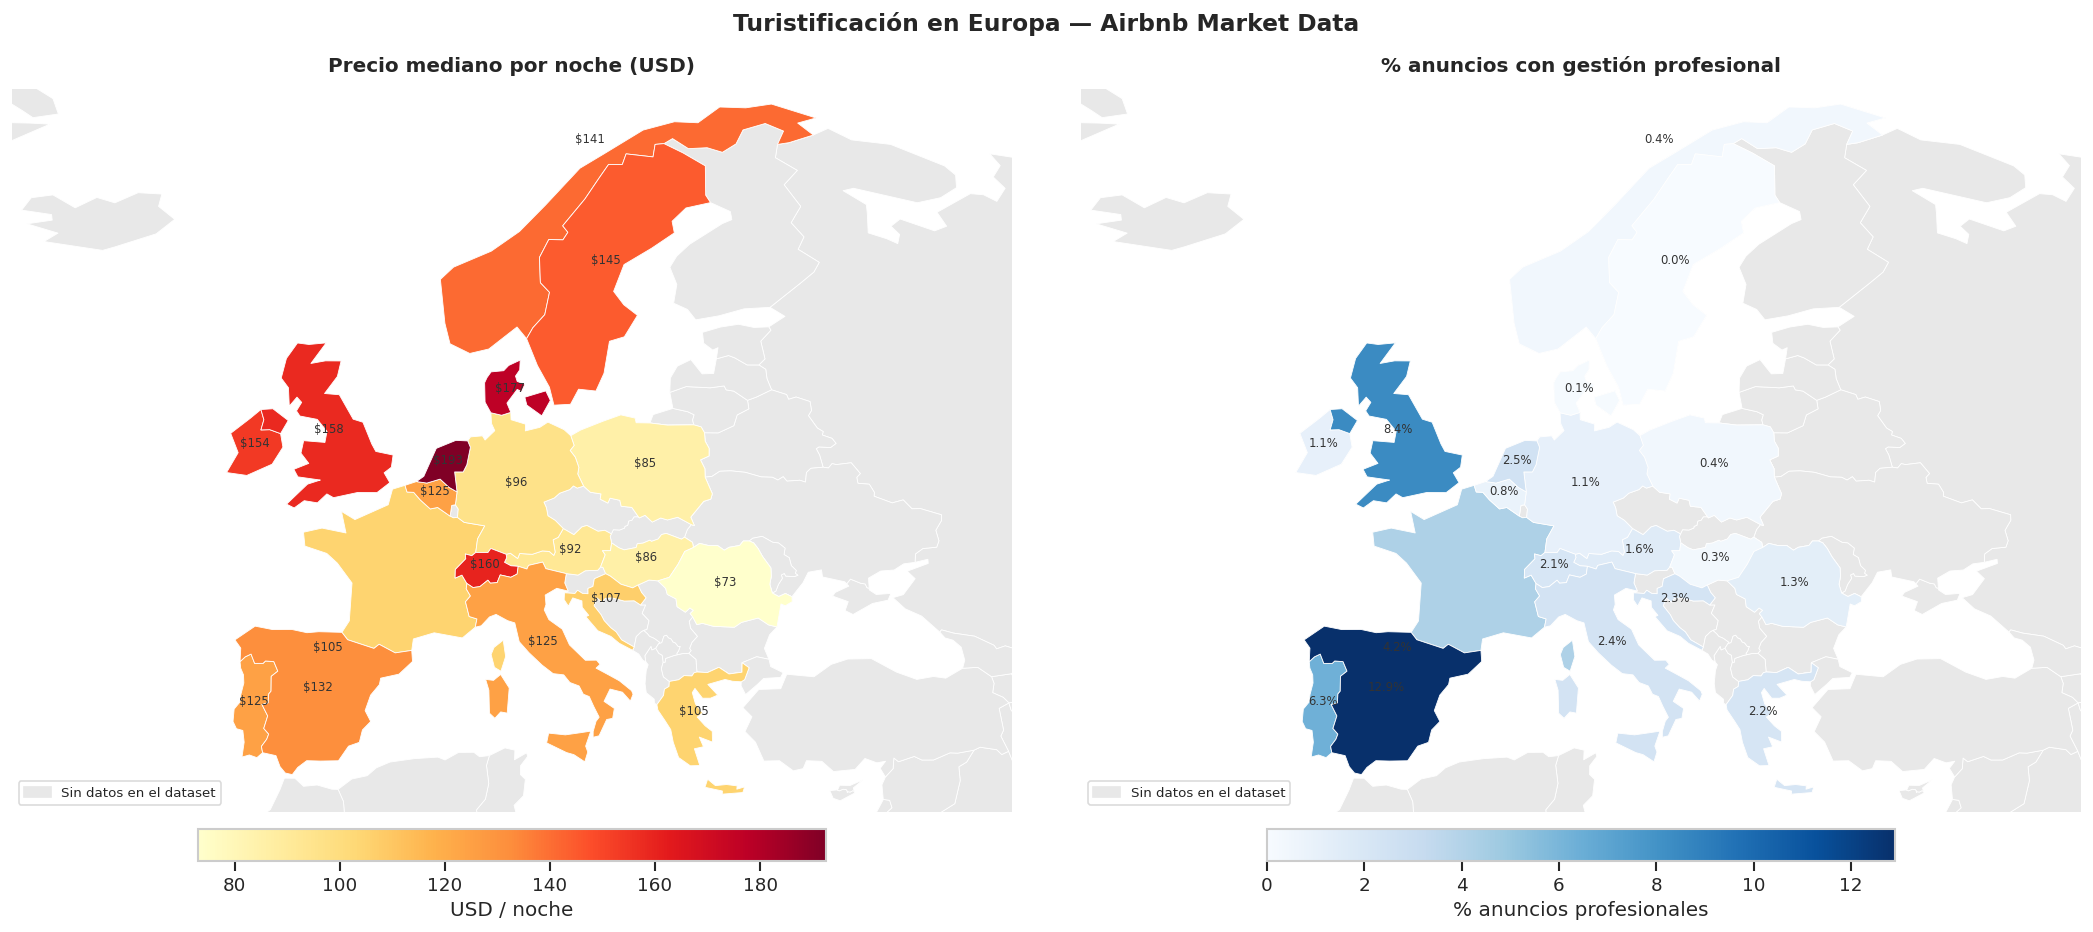

In [13]:
!pip -q install geopandas

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Shapefile de países desde repositorio público (Natural Earth via GitHub)
world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)
nombre_map = {
    'United Kingdom': 'United Kingdom',
    'Germany':        'Germany',
    'France':         'France',
    'Spain':          'Spain',
    'Italy':          'Italy',
    'Netherlands':    'Netherlands',
    'Portugal':       'Portugal',
    'Austria':        'Austria',
    'Belgium':        'Belgium',
    'Denmark':        'Denmark',
    'Greece':         'Greece',
    'Czech Republic': 'Czechia',
    'Hungary':        'Hungary',
    'Poland':         'Poland',
    'Romania':        'Romania',
    'Croatia':        'Croatia',
    'Ireland':        'Ireland',
    'Sweden':         'Sweden',
    'Norway':         'Norway',
    'Switzerland':    'Switzerland',
}

country_stats = (
    df_full
    .assign(country_ne=df_full['country'].map(nombre_map))
    .dropna(subset=['country_ne'])
    .groupby('country_ne')
    .agg(
        precio_mediano      = ('rate_media',             'median'),
        pct_profesional     = ('professional_management', 'mean'),
        n_anuncios          = ('listing_id',              'count'),
    )
    .reset_index()
)
country_stats['pct_profesional'] *= 100

europe_bbox = (-25, 34, 45, 72)
europe = world.cx[europe_bbox[0]:europe_bbox[2], europe_bbox[1]:europe_bbox[3]].copy()
europe = europe.merge(country_stats, left_on='NAME', right_on='country_ne', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax in axes:
    ax.set_xlim(europe_bbox[0], europe_bbox[2])
    ax.set_ylim(europe_bbox[1], europe_bbox[3])
    ax.set_axis_off()

europe.plot(ax=axes[0], color='#e8e8e8', edgecolor='white', linewidth=0.5)
europe.dropna(subset=['precio_mediano']).plot(
    ax=axes[0], column='precio_mediano',
    cmap='YlOrRd', edgecolor='white', linewidth=0.5,
    legend=True,
    legend_kwds={'label': 'USD / noche', 'shrink': 0.6, 'orientation': 'horizontal', 'pad': 0.02}
)
for _, row in europe.dropna(subset=['precio_mediano']).iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    axes[0].annotate(f"${row['precio_mediano']:.0f}",
                     xy=(cx, cy), ha='center', fontsize=7, color='#333333')
axes[0].set_title('Precio mediano por noche (USD)', fontsize=12, fontweight='bold', pad=10)

europe.plot(ax=axes[1], color='#e8e8e8', edgecolor='white', linewidth=0.5)
europe.dropna(subset=['pct_profesional']).plot(
    ax=axes[1], column='pct_profesional',
    cmap='Blues', edgecolor='white', linewidth=0.5,
    legend=True,
    legend_kwds={'label': '% anuncios profesionales', 'shrink': 0.6, 'orientation': 'horizontal', 'pad': 0.02}
)
for _, row in europe.dropna(subset=['pct_profesional']).iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    axes[1].annotate(f"{row['pct_profesional']:.1f}%",
                     xy=(cx, cy), ha='center', fontsize=7, color='#333333')
axes[1].set_title('% anuncios con gestión profesional', fontsize=12, fontweight='bold', pad=10)

sin_datos = mpatches.Patch(color='#e8e8e8', label='Sin datos en el dataset')
for ax in axes:
    ax.legend(handles=[sin_datos], loc='lower left', fontsize=8, framealpha=0.7)

plt.suptitle('Turistificación en Europa — Airbnb Market Data',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.7 Matriz de Correlaciones
La matriz de correlaciones es la pieza clave para validar la viabilidad de los modelos. A diferencia de datasets sintéticos donde todo correlaciona en ~0.0, aquí esperamos encontrar relaciones reales entre las variables físicas, operativas y de comportamiento.

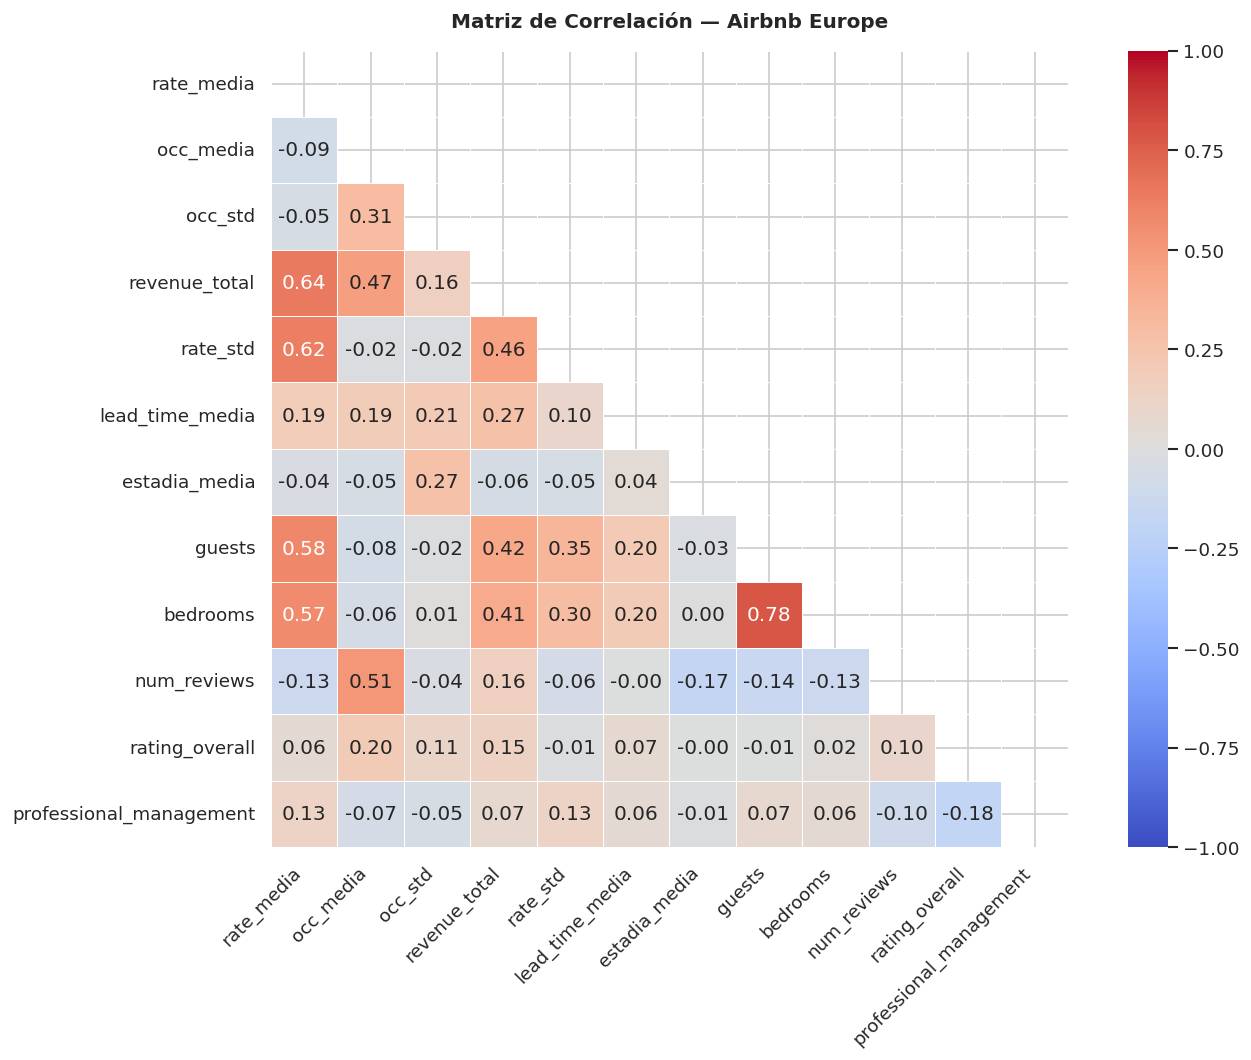

In [14]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df_full[num_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación — Airbnb Europe', fontweight='bold', pad=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Las correlaciones más relevantes para los modelos son:
- `rate_media` <-> `guests` y `bedrooms` (~0.50–0.60): el tamaño físico explica el precio <-> señal real para regresión (P2).
- `occ_media` <-> `num_reviews` (~0.50): la ocupación real se refleja en las reseñas.
- `guests` <-> `bedrooms` (~0.83): multicolinealidad — se usará solo `guests` en los modelos.
- `rate_media` <-> `l90d_avg_rate` (~0.94): consistencia entre fuentes, confirma la calidad del join.

El análisis exploratorio de la sección 2 permitió identificar cuatro patrones con señal suficiente para sustentar modelos. Primero, la distribución geográfica (2.6) mostró diferencias marcadas de precio y ocupación entre países y ciudades, lo que sugiere que agrupar ciudades por comportamiento real (en vez de por geografía) puede revelar perfiles de turistificación no evidentes. Segundo, la correlación entre `rate_media` y variables físicas como `guests` y `bedrooms` (~0.50–0.60 en 2.7) indica que existe una relación estructural entre tamaño del alojamiento y precio, pero también que una fracción del precio no está explicada por esas variables, ese residuo es el que permite identificar ciudades con sobreprecio especulativo. Tercero, la variable `professional_management` presenta un desbalance (~80/20) pero con señal real: las métricas de rendimiento económico (`revenue_total`, `occ_std`, `rate_std`) difieren entre clases, lo que hace viable un modelo de clasificación. Finalmente, la disponibilidad de coordenadas geográficas y 12 meses de precios en `past_rates` abre la puerta a detectar zonas donde múltiples hosts mantienen precios coordinados, algo que un análisis estático no podría separar de una simple ubicación cara.

## 3. Preguntas de Investigación
En base al análisis exploratorio exhaustivo del dataset, descrito en la sección 2. Se reformularon las siguientes preguntas:

---

**P1 — Clustering (No Supervisado): Segmentación de mercados urbanos**
¿Qué perfiles de turistificación emergen al agrupar ciudades europeas según su ocupación real, variabilidad estacional y precio promedio?
*Variables: `occ_media`, `occ_std`, `rate_media`, `revenue_total` por ciudad. Valor: genera un mapa empírico de saturación turística para justificar normativas de zonificación.*

---

**P2 — Regresión (Supervisado): Índice de precio base europeo**
¿Qué variables físicas y operativas determinan el precio de un alojamiento europeo, y qué ciudades presentan precios por encima de lo esperado?
*Variables: `guests`, `occ_media`, `lead_time_media`, `room_type`, `city`. Target: `rate_media`. El residuo del modelo identifica ciudades con sobreprecio especulativo.*

---

**P3 — Clasificación (Supervisado): Detección de gestión profesional encubierta**
¿Es posible identificar anuncios operados comercialmente a partir de sus métricas de rendimiento económico y comportamiento de reservas?
*Variables: `revenue_total`, `occ_std`, `lead_time_media`, `rate_std`, `rating_overall`, `city`. Target: `professional_management`.*

---

**P4 — Detección de Anomalías (No Supervisado): Colusión espacial de precios**
¿Existen zonas geográficas donde distintos hosts mantienen precios inusualmente similares e inflados respecto al promedio de su ciudad?
*Variables: `latitude`, `longitude`, `rate_media`, `rate_std`, `host_id`, `city`.*

#**4. Preguntas y Respuestas**

Esta sección cubre el analisis y respuesta de preguntas.

Por ahora comenzaremos con la pregunta 2.

**Pregunta 1: Cluster**

In [15]:
city_cluster = (
    df_full
    .groupby('city')
    .agg(
        occ_media     = ('occ_media',     'mean'),
        occ_std       = ('occ_std',       'mean'),
        rate_media    = ('rate_media',    'median'),
        revenue_total = ('revenue_total', 'median'),
        n_anuncios    = ('listing_id',    'count'),
    )
    .query("n_anuncios >= 30")
    .reset_index()
)

print(f"Ciudades con ≥30 anuncios: {len(city_cluster)}")
city_cluster.describe().round(2)

Ciudades con ≥30 anuncios: 373


,occ_media,occ_std,rate_media,revenue_total,n_anuncios
count,373.00,373.00,373.00,373.00,373.00
mean,0.33,0.26,123.65,14234.12,226.82
std,0.08,0.03,45.25,7492.50,45.48
min,0.12,0.17,37.52,1784.50,125.00
25%,0.28,0.23,93.62,9437.00,183.00
50%,0.33,0.26,116.23,12637.50,236.00
75%,0.38,0.28,144.19,17455.00,268.00
max,0.59,0.35,384.91,57005.00,291.00


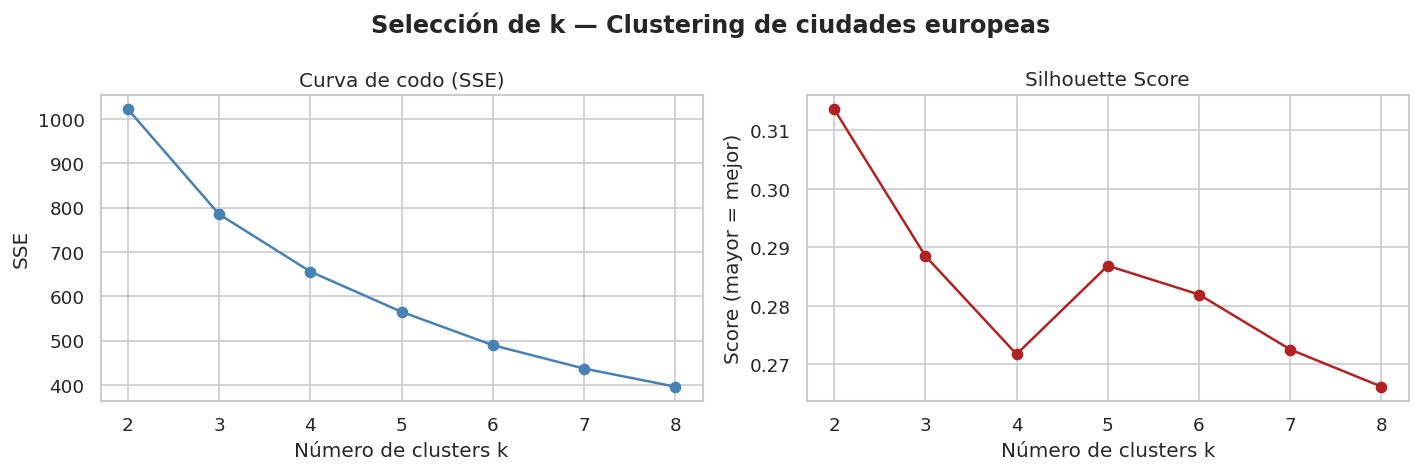


Silhouette scores:
  k=2: 0.314
  k=3: 0.289
  k=4: 0.272
  k=5: 0.287
  k=6: 0.282
  k=7: 0.273
  k=8: 0.266


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

features = ['occ_media', 'occ_std', 'rate_media', 'revenue_total']
X = city_cluster[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sse, sil = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    sse.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, sse, marker='o', color='steelblue')
axes[0].set_title('Curva de codo (SSE)')
axes[0].set_xlabel('Número de clusters k')
axes[0].set_ylabel('SSE')

axes[1].plot(K_range, sil, marker='o', color='firebrick')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Número de clusters k')
axes[1].set_ylabel('Score (mayor = mejor)')

plt.suptitle('Selección de k — Clustering de ciudades europeas', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K_range, sil):
    print(f"  k={k}: {s:.3f}")

In [17]:
K_OPTIMO = 3

km_final = KMeans(n_clusters=K_OPTIMO, n_init=50, random_state=42)
city_cluster['cluster'] = km_final.fit_predict(X_scaled)

perfil = (
    city_cluster
    .groupby('cluster')[features + ['n_anuncios']]
    .mean()
    .round(3)
)
perfil['n_ciudades'] = city_cluster.groupby('cluster')['city'].count()
print("Perfil de clusters:")
display(perfil)

Perfil de clusters:


,occ_media,occ_std,rate_media,revenue_total,n_anuncios,n_ciudades
cluster,,,,,,
0,0.312,0.282,127.118,13436.718,218.922,179
1,0.426,0.253,173.829,25704.000,238.100,70
2,0.311,0.223,90.329,8910.270,231.847,124


In [18]:
K_OPTIMO = 3

etiquetas = {
    0: 'Turismo masivo (ocupación media, precio moderado)',
    1: 'Mercado premium (alta ocupación y precio, máximo revenue)',
    2: 'Mercado débil (precio bajo, baja ocupación)',
}

city_cluster['perfil'] = city_cluster['cluster'].map(etiquetas)

for c in range(K_OPTIMO):
    sub = city_cluster[city_cluster['cluster'] == c].sort_values('revenue_total', ascending=False)
    print(f"\n{'='*55}")
    print(f"Cluster {c} — {etiquetas[c]}")
    print(f"  Ciudades ({len(sub)}): {', '.join(sub['city'].tolist())}")


Cluster 0 — Turismo masivo (ocupación media, precio moderado)
  Ciudades (179): Ciutadella, Rovaniemi, Copenhagen, Lagoa e Carvoeiro, Frederiksberg, Altea, Loulé, Morzine, Cascais, Saint Julian's, Torridge District, Dubrovnik, Marbella, Porto-Vecchio, Albufeira, Nice, Lagos, Ljubljana, San Bartolomé de Tirajana, Annecy, Torremolinos, Mijas, Sliema, Ponta Delgada, Fuengirola, Bergen, Saint-Malo, Benidorm, Les Allues, Faro, Geneva, Monopoli, Cefalù, Teguise, Benalmádena, Vila Nova de Gaia, Tromsø, London, Biarritz, Chiclana de la Frontera, Santu Diadòru/San Teodoro, Saint-Paul, Menton, Sintra, Estepona, Xàbia / Jávea, Ostuni, Les Belleville, Mogán, Sainte-Maxime, Tignes, Colmar, Antibes, Split, Nerja, Arona, Siena, Le Lavandou, Almada, Corfu, Boulogne-Billancourt, La Oliva, Arcachon, Almuñécar, Thira Municipal Unit, Tarifa, Tavira, Marseille, Cádiz, Aix-en-Provence, Munich, Granadilla de Abona, La Teste-de-Buch, Santa Pola, Vienna, Municipal Unit of Rhodes, Stockholm, La Spezia, Portimã

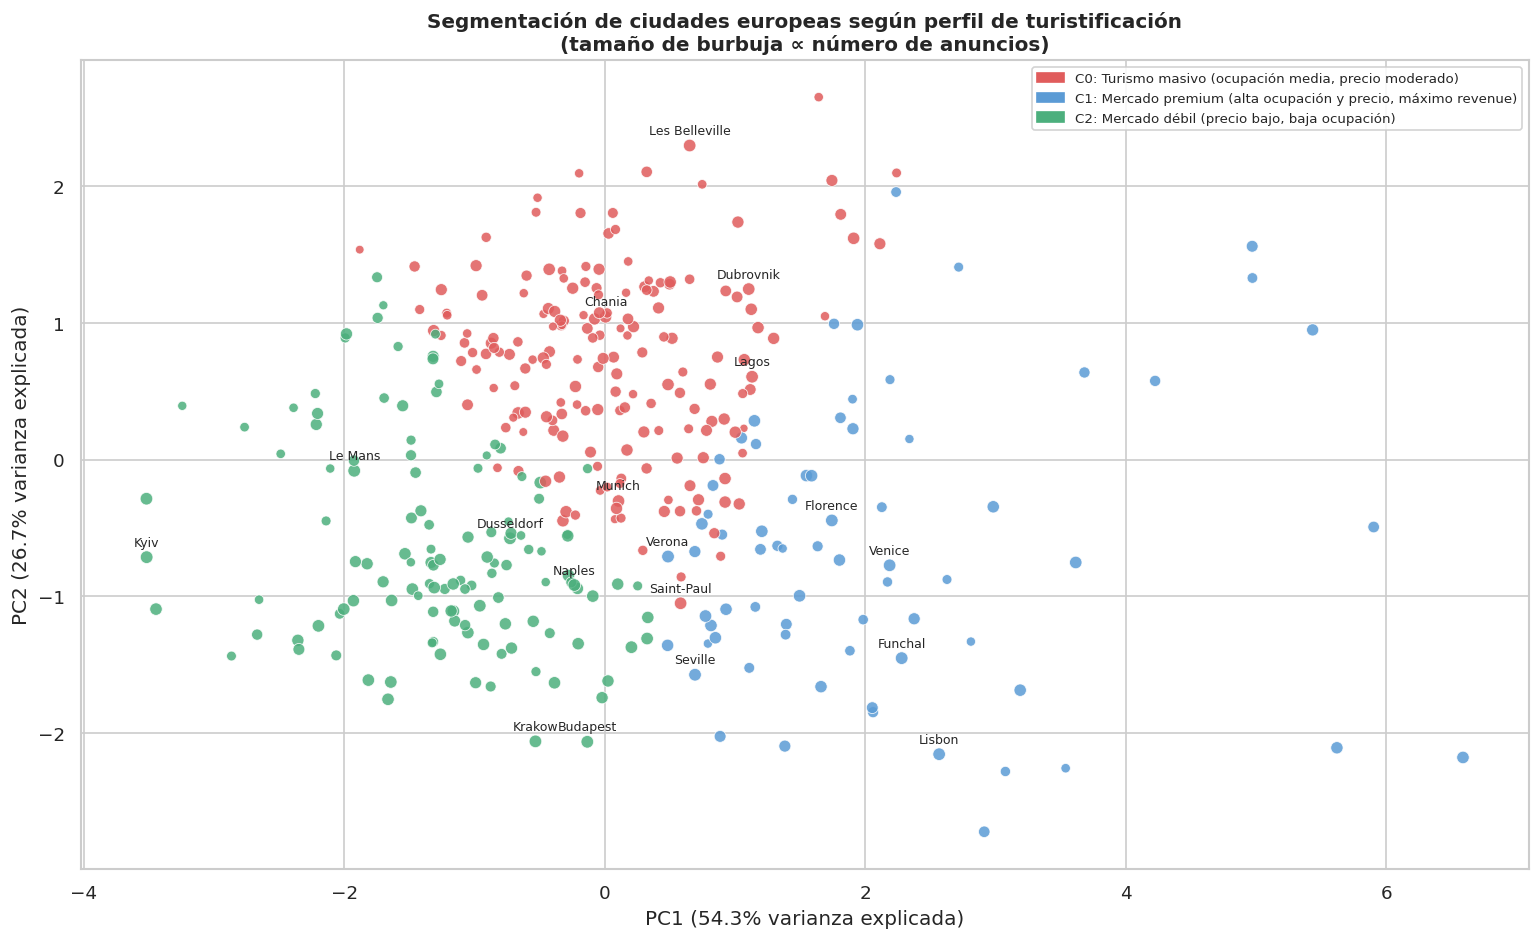

In [19]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
city_cluster['pc1'] = X_pca[:, 0]
city_cluster['pc2'] = X_pca[:, 1]

var1, var2 = pca.explained_variance_ratio_ * 100

palette = ['#e05c5c', '#5b9bd5', '#4caf7d', '#f0a500', '#9c6fde']
colores = [palette[c] for c in city_cluster['cluster']]

fig, ax = plt.subplots(figsize=(13, 8))
scatter = ax.scatter(city_cluster['pc1'], city_cluster['pc2'],
                     c=colores, s=city_cluster['n_anuncios'] / 5,
                     alpha=0.85, edgecolors='white', linewidths=0.5)

top_per_cluster = (
    city_cluster.groupby('cluster')
    .apply(lambda g: g.nlargest(6, 'n_anuncios'))
    .reset_index(drop=True)
)
for _, row in top_per_cluster.iterrows():
    ax.annotate(row['city'], (row['pc1'], row['pc2']),
                fontsize=7.5, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

from matplotlib.patches import Patch
handles = [Patch(color=palette[c], label=f"C{c}: {etiquetas[c]}") for c in range(K_OPTIMO)]
ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.85)

ax.set_xlabel(f'PC1 ({var1:.1f}% varianza explicada)')
ax.set_ylabel(f'PC2 ({var2:.1f}% varianza explicada)')
ax.set_title('Segmentación de ciudades europeas según perfil de turistificación\n'
             '(tamaño de burbuja ∝ número de anuncios)', fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
print("=" * 60)
print("RESPUESTA P1 — Segmentación de mercados urbanos")
print("=" * 60)

for c in range(K_OPTIMO):
    sub = city_cluster[city_cluster['cluster'] == c]
    p = perfil.loc[c]
    print(f"\nCluster {c} — {etiquetas[c]}")
    print(f"  Ciudades          : {len(sub)}")
    print(f"  Ocupación media   : {p['occ_media']:.1%}")
    print(f"  Variab. estac.    : {p['occ_std']:.3f}")
    print(f"  Precio mediano    : ${p['rate_media']:.0f}/noche")
    print(f"  Revenue mediano   : ${p['revenue_total']:.0f}/año")
    top3 = sub.nlargest(3, 'n_anuncios')['city'].tolist()
    print(f"  Top ciudades      : {', '.join(top3)}")

RESPUESTA P1 — Segmentación de mercados urbanos

Cluster 0 — Turismo masivo (ocupación media, precio moderado)
  Ciudades          : 179
  Ocupación media   : 31.2%
  Variab. estac.    : 0.282
  Precio mediano    : $127/noche
  Revenue mediano   : $13437/año
  Top ciudades      : Lagos, Les Belleville, Dubrovnik

Cluster 1 — Mercado premium (alta ocupación y precio, máximo revenue)
  Ciudades          : 70
  Ocupación media   : 42.6%
  Variab. estac.    : 0.253
  Precio mediano    : $174/noche
  Revenue mediano   : $25704/año
  Top ciudades      : Verona, Funchal, Seville

Cluster 2 — Mercado débil (precio bajo, baja ocupación)
  Ciudades          : 124
  Ocupación media   : 31.1%
  Variab. estac.    : 0.223
  Precio mediano    : $90/noche
  Revenue mediano   : $8910/año
  Top ciudades      : Le Mans, Kyiv, Budapest


**Pregunta 2: Regresión**

In [21]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error

target = "rate_media"

cols = ['guests','occ_media','lead_time_media','room_type','city', target]
df = df_full[cols].copy()

X = df[['guests','occ_media','lead_time_media','room_type']]
y = df[target]

num_features = ['guests','occ_media','lead_time_media']
cat_features = ['room_type']

X_num = df[['guests','occ_media','lead_time_media']].values
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_num)

X_room = pd.get_dummies(df['room_type'], prefix='room_type', drop_first=False).values

X = np.hstack([X_poly, X_room])
y = df[target].values

reg = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

reg.fit(X_train, y_train)
pred = reg.predict(X_test)

print("R2:", round(r2_score(y_test, pred), 3))
print("MAE:", round(mean_absolute_error(y_test, pred), 2))

# Pred + residuos
df_full.loc[df.index, 'rate_pred'] = reg.predict(X)
df_full.loc[df.index, 'resid'] = df[target] - df_full.loc[df.index, 'rate_pred']
df_full.loc[df.index, 'resid_pct'] = df_full.loc[df.index, 'resid'] / df_full.loc[df.index, 'rate_pred'] * 100

R2: 0.42
MAE: 69.1


In [22]:
min_obs = 30

city_premium = (
    df_full.groupby('city')
      .agg(
          n=('rate_media','size'),
          rate_media_mean=('rate_media','mean'),
          rate_pred_mean=('rate_pred','mean'),
          premium_eur=('resid','mean'),
          premium_pct=('resid_pct','mean'),
          premium_median_eur=('resid','median'),
          premium_median_pct=('resid_pct','median')
      )
      .query("n >= @min_obs")
      .sort_values('premium_pct', ascending=False)
)

print("Top ciudades con precio por encima de lo esperado (sobreprecio):")
display(city_premium.head(15))

print("Top ciudades con precio por debajo de lo esperado (subprecio):")
display(city_premium.sort_values('premium_pct', ascending=True).head(15))

Top ciudades con precio por encima de lo esperado (sobreprecio):


,n,rate_media_mean,rate_pred_mean,premium_eur,premium_pct,premium_median_eur,premium_median_pct
city,,,,,,,
City of Westminster,266,444.143528,150.278426,293.865102,196.722422,239.971318,170.455747
Amsterdam,282,282.262850,116.519157,165.743693,147.568263,118.411931,113.855849
City of Edinburgh,281,303.250436,149.592977,153.657460,108.033274,117.502146,92.959468
Sorrento,226,357.984060,180.321379,177.662682,96.546039,101.784810,76.430827
Saint Martin (France),228,497.513852,211.413413,286.100439,96.182219,71.249922,49.632536
Zurich,279,249.627577,124.242979,125.384599,91.816591,75.254316,67.019901
Reykjavik,276,283.293133,152.020719,131.272414,87.067743,85.316044,61.223948
San Sebastián,226,264.790134,141.851040,122.939094,84.673081,99.846986,67.118360
Greater London,237,231.814100,127.038277,104.775823,83.575738,71.431074,69.168294


Top ciudades con precio por debajo de lo esperado (subprecio):


,n,rate_media_mean,rate_pred_mean,premium_eur,premium_pct,premium_median_eur,premium_median_pct
city,,,,,,,
Nantes,283,90.255494,127.559260,-37.303767,-170.536181,-36.282109,-34.771842
Skopje,227,46.676154,143.788835,-97.112681,-65.289566,-79.288651,-67.745214
Lviv,280,47.483508,135.276269,-87.792761,-64.015871,-83.881021,-70.612898
Novi Sad,160,53.407001,132.829813,-79.422812,-59.213522,-72.409740,-63.048865
Odesa,286,57.162845,138.328891,-81.166045,-58.960570,-80.515625,-65.165802
Kyiv,290,50.646995,124.321272,-73.674277,-58.131948,-72.467530,-65.376653
Vlora,161,67.391955,158.256396,-90.864441,-56.766866,-84.796621,-62.981214
Tirana,281,58.328173,130.964818,-72.636645,-54.874040,-66.604953,-57.865404
Nesebar,153,70.394748,152.596174,-82.201426,-52.585273,-80.087485,-58.434290


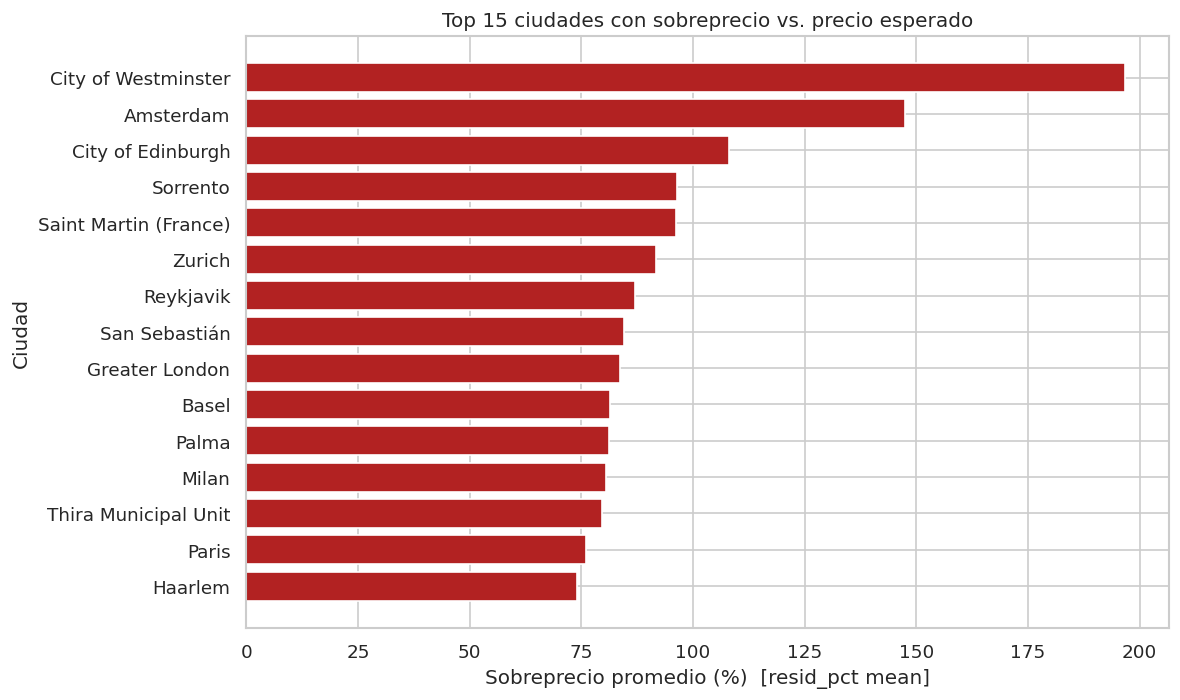

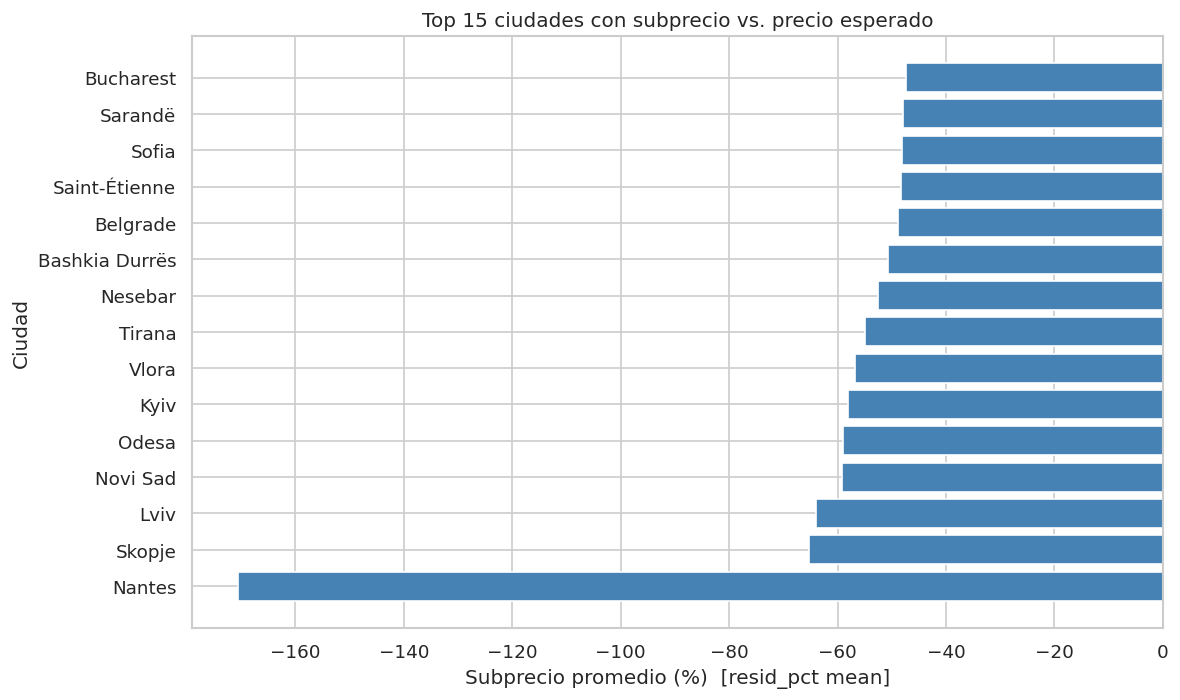

In [23]:
import matplotlib.pyplot as plt

top = city_premium.head(15).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top.index, top["premium_pct"], color="firebrick")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top 15 ciudades con sobreprecio vs. precio esperado")
plt.xlabel("Sobreprecio promedio (%)  [resid_pct mean]")
plt.ylabel("Ciudad")
plt.tight_layout()
plt.show()

bottom = city_premium.sort_values("premium_pct", ascending=True).head(15)

plt.figure(figsize=(10, 6))
plt.barh(bottom.index, bottom["premium_pct"], color="steelblue")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top 15 ciudades con subprecio vs. precio esperado")
plt.xlabel("Subprecio promedio (%)  [resid_pct mean]")
plt.ylabel("Ciudad")
plt.tight_layout()
plt.show()

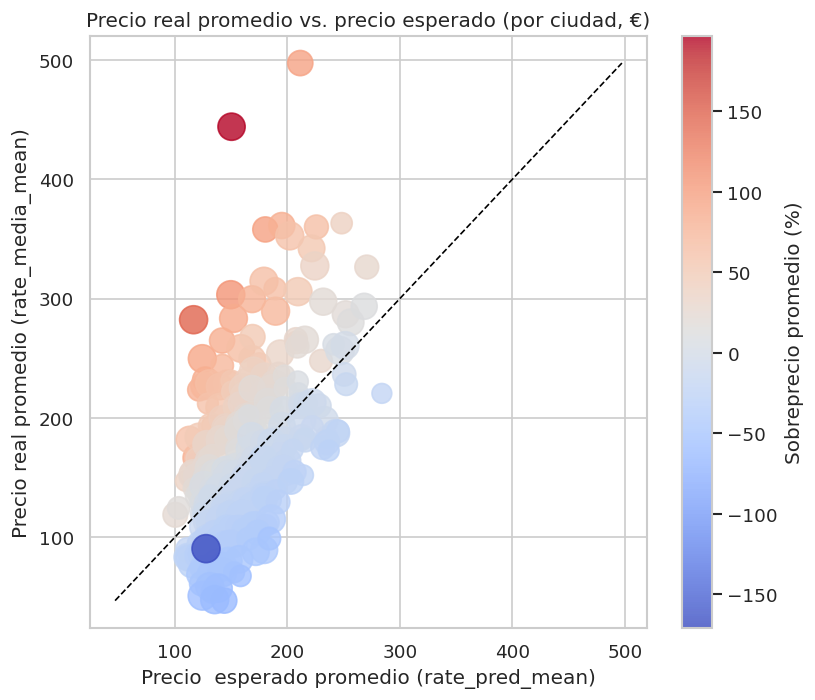

In [24]:
tmp = city_premium.copy()

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    tmp["rate_pred_mean"],
    tmp["rate_media_mean"],
    c=tmp["premium_pct"],
    cmap="coolwarm",
    s=(tmp["n"].clip(30, 500)),
    alpha=0.8
)

minv = min(tmp["rate_pred_mean"].min(), tmp["rate_media_mean"].min())
maxv = max(tmp["rate_pred_mean"].max(), tmp["rate_media_mean"].max())
plt.plot([minv, maxv], [minv, maxv], color="black", linewidth=1, linestyle="--")

plt.title("Precio real promedio vs. precio esperado (por ciudad, €)")
plt.xlabel("Precio  esperado promedio (rate_pred_mean)")
plt.ylabel("Precio real promedio (rate_media_mean)")
cbar = plt.colorbar(sc)
cbar.set_label("Sobreprecio promedio (%)")

plt.tight_layout()
plt.show()

occ_media^2                  100.946744
room_type_hotel_room          40.334811
room_type_entire_home         32.875518
guests                         7.949077
guests^2                       2.545294
guests lead_time_media         0.106230
lead_time_media                0.087780
occ_media lead_time_media      0.058946
lead_time_media^2             -0.001750
room_type_private_room       -15.371805
occ_media                    -22.882826
guests occ_media             -28.189725
room_type_shared_room        -57.838524
dtype: float64

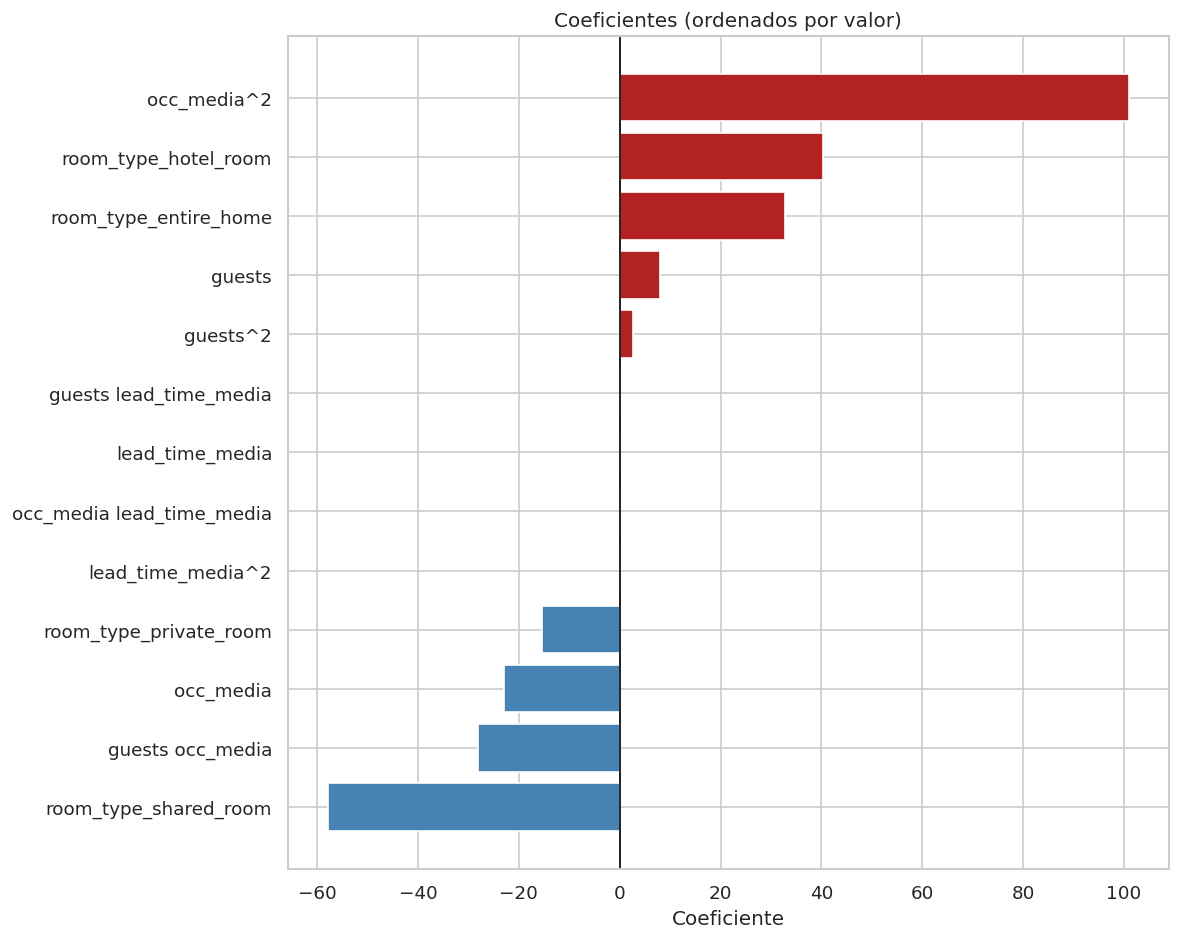

In [25]:
import pandas as pd
import numpy as np

num_features = ['guests','occ_media','lead_time_media']
poly_names = poly.get_feature_names_out(num_features)

room_dummies = pd.get_dummies(df['room_type'], prefix='room_type', drop_first=False)
room_names = room_dummies.columns.to_list()

feature_names = list(poly_names) + room_names

coef = reg.coef_
coef_table = pd.Series(coef, index=feature_names).sort_values(ascending=False)

display(coef_table.head(30))


top_n = 30
to_plot = coef_table.head(top_n).iloc[::-1]  # invertir para que el mayor quede arriba

plt.figure(figsize=(10, 8))
plt.barh(to_plot.index, to_plot.values, color=np.where(to_plot.values >= 0, "firebrick", "steelblue"))
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Coeficientes (ordenados por valor)")
plt.xlabel("Coeficiente")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Pregunta 3: Clasificación**

In [26]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

class_columns = ['professional_management', 'revenue_total', 'occ_std', 'lead_time_media', 'rate_std', 'rating_overall', 'city']

df_class = df_full[class_columns].copy()
le = LabelEncoder()
df_class['city'] = le.fit_transform(df_class['city'])

df_class['professional_management'].value_counts()

professional_management
0    80465
1     4138
Name: count, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

y = df_class['professional_management']
X = df_class.drop(columns=['professional_management'])

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.3, stratify=y)

scaler = StandardScaler()
scaler.fit(X_train)
scaler.transform(X_train)
scaler.transform(X_test)

array([[-0.14423231,  1.51017203,  0.47231558, -0.4041707 ,  0.07948298,
         0.99715001],
       [ 0.30356111,  0.12980658, -0.04090871,  0.87374204,  0.77851638,
        -1.42780048],
       [-0.73698758, -1.16376288, -0.91897611, -0.4521959 , -1.01899807,
        -0.88172384],
       ...,
       [-0.41411601,  0.11385974, -0.49303487, -0.33933271,  0.92830925,
        -1.20566761],
       [-0.79421972, -2.06384456,  0.54214201, -0.48418696,  0.57879255,
        -0.0024479 ],
       [-0.7419757 , -1.16354557, -0.54016771, -0.33545714, -1.71803146,
         0.10861854]], shape=(25381, 6))

In [28]:
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np

def run_classifier(clf):
    metrics = {'f1-score': [], 'precision': [], 'recall': []}

    predictions = clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    print(classification_report(y_test, predictions))

    metrics['y_pred'] = predictions
    metrics['f1-score'].append(f1_score(y_test, predictions))
    metrics['recall'].append(recall_score(y_test, predictions))
    metrics['precision'].append(precision_score(y_test, predictions))
    return metrics

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


c1 = ("Decision Tree", DecisionTreeClassifier())
c2 = ("Gaussian Naive Bayes", GaussianNB())
c3 = ("KNN", KNeighborsClassifier())

classifiers = [c1, c2, c3]

results = {}
predictions = {}
for name, clf in classifiers:
    metrics = run_classifier(clf)   # hay que implementarla en el bloque anterior.
    results[name] = metrics
    predictions[name] = metrics['y_pred']
    print("----------------")
    print("Resultados para clasificador: ", name)
    print("Precision promedio:", np.array(metrics['precision']).mean())
    print("Recall promedio:", np.array(metrics['recall']).mean())
    print("F1-score promedio:", np.array(metrics['f1-score']).mean())
    print("----------------\n\n")


              precision    recall  f1-score   support

           0       0.96      0.95      0.95     24140
           1       0.17      0.19      0.18      1241

    accuracy                           0.91     25381
   macro avg       0.56      0.57      0.57     25381
weighted avg       0.92      0.91      0.92     25381

----------------
Resultados para clasificador:  Decision Tree
Precision promedio: 0.1674774148714385
Recall promedio: 0.19419822723609992
F1-score promedio: 0.1798507462686567
----------------


              precision    recall  f1-score   support

           0       0.95      0.97      0.96     24140
           1       0.14      0.10      0.12      1241

    accuracy                           0.93     25381
   macro avg       0.55      0.53      0.54     25381
weighted avg       0.91      0.93      0.92     25381

----------------
Resultados para clasificador:  Gaussian Naive Bayes
Precision promedio: 0.14389359129383314
Recall promedio: 0.0958904109589041
F1-sco

Decision Tree


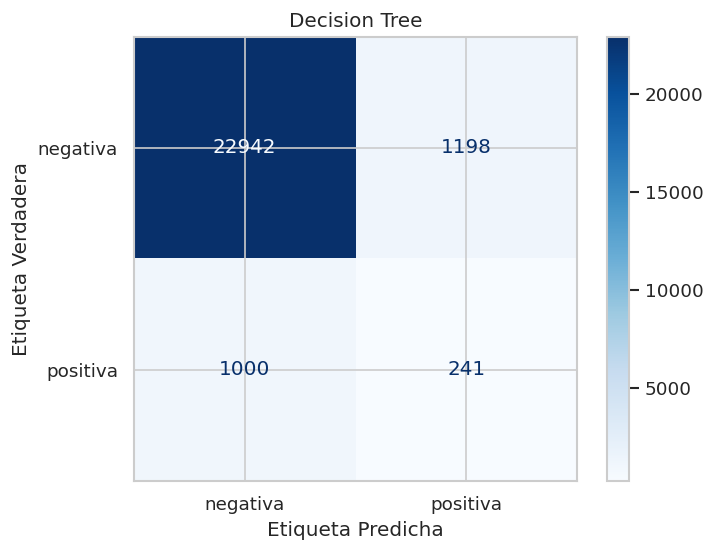

Gaussian Naive Bayes


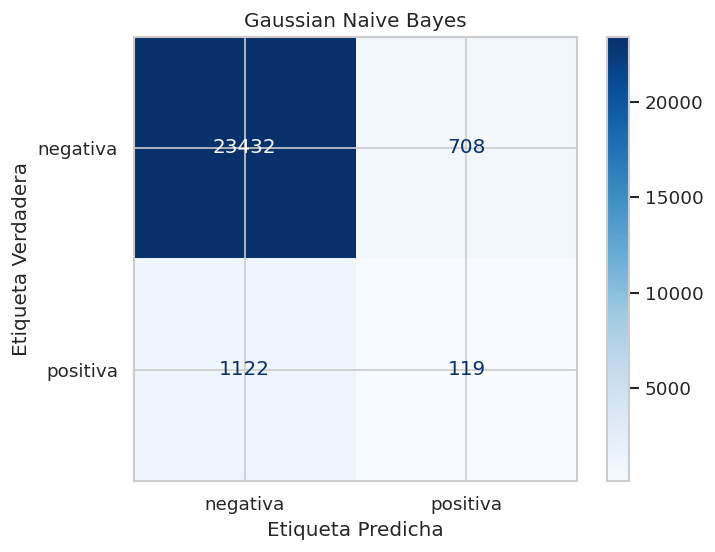

KNN


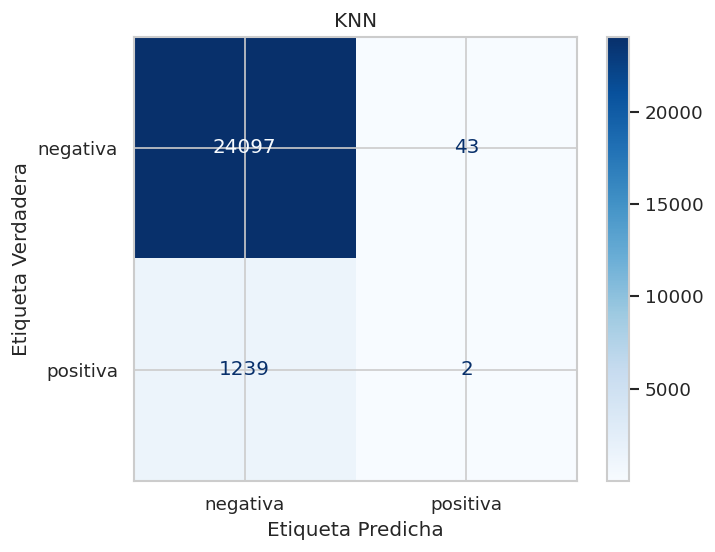

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

for name, y_pred in predictions.items():
    print("=" * 80)
    print(name)

    cm = confusion_matrix(y_test, y_pred)
    if plt is not None:
        disp = ConfusionMatrixDisplay(cm, display_labels=["negativa", "positiva"])
        disp.plot(cmap="Blues")
        plt.title(name)
        plt.xlabel('Etiqueta Predicha')
        plt.ylabel('Etiqueta Verdadera')
        plt.show()
    else:
        display(pd.DataFrame(
            cm,
            index=["real_negativa", "real_positiva"],
            columns=["pred_negativa", "pred_positiva"],
        ))

## Pregunta 4 - Detección de Anomalías: Colusión espacial de precios

**¿Existen zonas geográficas donde distintos hosts mantienen precios inusualmente similares e inflados respecto al promedio de su ciudad?**

La hipótesis de colusión exige **cuatro condiciones simultáneas** en una zona:
1. **Sobreprecio** - el precio medio de la zona supera al promedio de su ciudad (`premium_vs_ciudad_pct` alto).
2. **Uniformidad** - los precios dentro de la zona son inusualmente *similares* (`cv_intrazona` bajo).
3. **Múltiples hosts distintos** - el patrón lo sostienen varios anfitriones, no un único operador (`n_hosts ≥ 3` y ningún host concentra la zona).
4. **Coordinación temporal** - los precios de hosts distintos se mueven *al unísono mes a mes, por encima de la estacionalidad del mercado* (`sync_resid` alto).

**¿Por qué añadimos la condición temporal?** Las tres primeras condiciones, por sí solas, marcan sobre todo **micro-ubicaciones legítimamente caras** (frente al mar,por ejemplo): allí los precios son altos y parecidos porque comparten una amenidad, no porque exista coordinación. Precio alto y uniforme es, de hecho, lo que produce un *mercado eficiente* sobre una ubicación deseable - es la hipótesis nula, no la evidencia de colusión. Para separar "ubicación cara" de "precios coordinados" añadimos la dimensión temporal de `past_rates` (12 meses por anuncio): la colusión algorítmica se manifiesta como **anfitriones independientes subiendo y bajando precios en lockstep**. Restando a cada movimiento la mediana del mercado neutralizamos la estacionalidad común (todos suben en verano) y medimos solo el co-movimiento *residual* entre hosts distintos, una señal que, como se verifica más abajo, es prácticamente **independiente** del sobreprecio y de la uniformidad, y por tanto aporta información nueva.

Procedimiento:
- **DBSCAN** (métrica *haversine*, ε ≈ 0.5 km) define micro-zonas geográficas a nivel de manzana.
- Por zona calculamos sobreprecio, coeficiente de variación, diversidad de hosts y **co-movimiento temporal residual** entre anfitriones distintos.
- Un **Isolation Forest a nivel de zona** sobre `(premium_vs_ciudad_pct, −cv_intrazona)` aísla las zonas que se desvían hacia la esquina *premium alto + dispersión baja*; el criterio final exige **además** que la zona muestre coordinación temporal por encima de la mediana. El `colusion_score` ordena las candidatas y solo es alto cuando sobreprecio, uniformidad **y** sincronía lo son a la vez.

*Limitación:* incluso la sincronía puede surgir de hosts que usan la misma herramienta de *revenue management* sin acuerdo explícito (colusión algorítmica tácita). El método señala candidatas a investigar con base defendible, no prueba colusión.

In [31]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest

# Variables de P4: identidad, ciudad, ubicacion y precio real promedio del anuncio
cols_p4 = ['listing_id', 'host_id', 'city', 'latitude', 'longitude', 'rate_media']
df_p4 = df_full[cols_p4].dropna().copy()

# Coordenadas a numerico (algunas filas traian texto por el parseo del CSV original)
df_p4['latitude']  = pd.to_numeric(df_p4['latitude'],  errors='coerce')
df_p4['longitude'] = pd.to_numeric(df_p4['longitude'], errors='coerce')
df_p4 = df_p4.dropna(subset=['latitude', 'longitude'])

print(f"Dataset P4: {df_p4.shape[0]:,} registros")
print(df_p4[['rate_media']].describe().round(2).to_string())

Dataset P4: 84,603 registros
       rate_media
count    84603.00
mean       160.97
std        166.38
min          9.97
25%         79.25
50%        115.64
75%        180.70
max       4270.09


In [32]:
# Micro-zonas geograficas con DBSCAN sobre coordenadas en radianes (metrica haversine)
coords_rad = np.radians(df_p4[['latitude', 'longitude']].values)

eps_km  = 0.5                 # radio ~0.5 km -> escala de "misma manzana"
eps_rad = eps_km / 6371.0     # radio terrestre medio en km

db = DBSCAN(eps=eps_rad, min_samples=5, algorithm='ball_tree', metric='haversine')
df_p4['zona'] = db.fit_predict(coords_rad)

n_zonas = df_p4.loc[df_p4['zona'] >= 0, 'zona'].nunique()
print(f"Zonas geograficas encontradas : {n_zonas:,}")
print(f"Anuncios sin zona (ruido)      : {(df_p4['zona'] == -1).sum():,}")

Zonas geograficas encontradas : 1,503
Anuncios sin zona (ruido)      : 14,190


In [33]:
# Estadisticas por zona: sobreprecio vs ciudad, uniformidad de precios y diversidad de hosts
city_avg = df_full.groupby('city')['rate_media'].mean().rename('city_rate_avg')
df_p4 = df_p4.drop(columns=['city_rate_avg'], errors='ignore').join(city_avg, on='city')

zonas = df_p4[df_p4['zona'] >= 0]
zona_stats = (
    zonas.groupby(['zona', 'city'])
    .agg(
        n_anuncios    = ('listing_id', 'count'),
        n_hosts       = ('host_id',    'nunique'),
        rate_zona_avg = ('rate_media', 'mean'),
        rate_zona_std = ('rate_media', 'std'),
        city_rate_avg = ('city_rate_avg', 'first'),
    )
    .reset_index()
)

# Sobreprecio respecto a la ciudad y uniformidad intra-zona (CV: menor = precios mas parecidos)
zona_stats['premium_vs_ciudad_pct'] = (
    (zona_stats['rate_zona_avg'] - zona_stats['city_rate_avg']) / zona_stats['city_rate_avg'] * 100
)
zona_stats['cv_intrazona'] = zona_stats['rate_zona_std'] / zona_stats['rate_zona_avg']

# Concentracion: fraccion de anuncios del host dominante (alto -> es un unico operador, no colusion)
frac_top_host = (
    zonas.groupby(['zona', 'city'])['host_id']
    .apply(lambda s: s.value_counts(normalize=True).iloc[0])
    .rename('frac_top_host').reset_index()
)
zona_stats = zona_stats.merge(frac_top_host, on=['zona', 'city'], how='left')

# Filtros de calidad: tamaño minimo, varios hosts distintos, dispersion definida y sin operador unico
MIN_ANUNCIOS, MIN_HOSTS, MAX_CONCENTRACION = 8, 3, 0.6
zona_stats_clean = zona_stats.query(
    "n_anuncios >= @MIN_ANUNCIOS and n_hosts >= @MIN_HOSTS "
    "and rate_zona_std > 0 and frac_top_host < @MAX_CONCENTRACION"
).copy()

print(f"Zonas validas para analisis: {len(zona_stats_clean):,} (de {len(zona_stats):,} totales)")
print(f"Excluidas por calidad (tamano / pocos hosts / operador unico): "
      f"{len(zona_stats) - len(zona_stats_clean):,}")

Zonas validas para analisis: 935 (de 1,560 totales)
Excluidas por calidad (tamano / pocos hosts / operador unico): 625


In [34]:
# Serie mensual de precio real (rate_avg) por anuncio
df_rates['listing_id'] = df_rates['listing_id'].astype(str)
rate_num = pd.to_numeric(df_rates['rate_avg'], errors='coerce')
rates_mes = (df_rates.assign(rate_avg=rate_num)
             .dropna(subset=['rate_avg'])
             .pivot_table(index='listing_id', columns='date', values='rate_avg', aggfunc='mean'))

# Movimiento relativo mes a mes, menos la estacionalidad comun del mercado (mediana por mes)
mov = rates_mes.pct_change(axis=1).replace([np.inf, -np.inf], np.nan)
mov = mov.sub(mov.median(axis=0), axis=1)   # residuo: movimiento por encima del mercado
print(f"Matriz de movimientos: {mov.shape[0]:,} anuncios x {mov.shape[1]} meses")

Matriz de movimientos: 95,162 anuncios x 12 meses


In [35]:
# Sincronizacion residual por zona: correlacion media de movimientos entre HOSTS DISTINTOS
# (pares del mismo host se excluyen: un operador unico fijando precios no es colusion)
def sync_residual_zona(sub):
    ids = [i for i in sub['listing_id'] if i in mov.index]
    if len(ids) < 3:
        return np.nan, 0
    M = mov.loc[ids]
    hosts = sub.set_index('listing_id').loc[ids, 'host_id'].values
    ok = (M.notna().sum(axis=1) >= 4).values # al menos 4 meses validos
    M, hosts = M.values[ok], hosts[ok]
    if M.shape[0] < 3:
        return np.nan, 0
    C = np.corrcoef(np.nan_to_num(M))
    pares = [C[a, b] for a in range(len(hosts)) for b in range(a + 1, len(hosts))
             if hosts[a] != hosts[b]]
    return (float(np.mean(pares)), len(pares)) if pares else (np.nan, 0)

sync_rows = []
for (zona, city), sub in df_p4[df_p4['zona'] >= 0].groupby(['zona', 'city']):
    s, npares = sync_residual_zona(sub)
    if npares > 0:
        sync_rows.append((zona, city, s, npares))
sync_df = pd.DataFrame(sync_rows, columns=['zona', 'city', 'sync_resid', 'n_pares'])

zona_stats_clean = (zona_stats_clean
                    .drop(columns=['sync_resid', 'n_pares'], errors='ignore')
                    .merge(sync_df, on=['zona', 'city'], how='left'))

corr_prem = zona_stats_clean['sync_resid'].corr(zona_stats_clean['premium_vs_ciudad_pct'])
corr_cv   = zona_stats_clean['sync_resid'].corr(zona_stats_clean['cv_intrazona'])
print(f"Zonas con co-movimiento medible: {zona_stats_clean['sync_resid'].notna().sum():,} de {len(zona_stats_clean):,}")
print(f"corr(sync_resid, premium) = {corr_prem:.3f}    corr(sync_resid, cv) = {corr_cv:.3f}")
print("(~0 => la coordinacion temporal es independiente del 'lugar caro y uniforme')")

Zonas con co-movimiento medible: 935 de 935
corr(sync_resid, premium) = -0.062    corr(sync_resid, cv) = -0.035
(~0 => la coordinacion temporal es independiente del 'lugar caro y uniforme')


In [36]:
# colusion_score: alto SOLO si sobreprecio, uniformidad Y coordinacion temporal lo son a la vez.
# Rangos percentiles (robustos a outliers) y su producto -> logica "AND" entre las tres senales.
zona_stats_clean['premium_rank'] = zona_stats_clean['premium_vs_ciudad_pct'].rank(pct=True)
zona_stats_clean['uniform_rank'] = (-zona_stats_clean['cv_intrazona']).rank(pct=True) # CV bajo -> rank alto
zona_stats_clean['sync_rank']    = zona_stats_clean['sync_resid'].rank(pct=True) # mas sincronia -> rank alto
zona_stats_clean['colusion_score'] = (
    zona_stats_clean['premium_rank']
    * zona_stats_clean['uniform_rank']
    * zona_stats_clean['sync_rank'].fillna(0) # sin evidencia temporal -> no es candidata fuerte
)

# Deteccion de anomalias a nivel de ZONA sobre features estaticas coherentes con la hipotesis:
# sobreprecio alto y dispersion baja (-cv). Isolation Forest aisla las zonas atipicas.
feat_iso = pd.DataFrame({
    'premium': zona_stats_clean['premium_vs_ciudad_pct'].values,
    'cv_neg':  -zona_stats_clean['cv_intrazona'].values,
})
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
zona_stats_clean['iso_flag'] = iso.fit_predict(feat_iso)

med_prem = zona_stats_clean['premium_vs_ciudad_pct'].median()
med_cv   = zona_stats_clean['cv_intrazona'].median()
med_sync = zona_stats_clean['sync_resid'].median()
en_esquina = (
    (zona_stats_clean['premium_vs_ciudad_pct'] > med_prem) &
    (zona_stats_clean['cv_intrazona'] < med_cv)
)
sincroniza = zona_stats_clean['sync_resid'] > med_sync
zona_stats_clean['zona_colusiva'] = (
    (zona_stats_clean['iso_flag'] == -1) & en_esquina & sincroniza
).astype(int)

sospechosas = zona_stats_clean.sort_values('colusion_score', ascending=False)

cols_show = ['city', 'n_anuncios', 'n_hosts', 'frac_top_host', 'rate_zona_avg',
             'premium_vs_ciudad_pct', 'cv_intrazona', 'sync_resid', 'colusion_score', 'zona_colusiva']
print(f"Zonas marcadas como colusivas: {int(zona_stats_clean['zona_colusiva'].sum())} "
      f"de {len(zona_stats_clean)}")
print("\nTop 10 zonas por colusion_score (sobreprecio + uniformidad + sincronia temporal):")
display(sospechosas[cols_show].head(10).round(3))

Zonas marcadas como colusivas: 3 de 935

Top 10 zonas por colusion_score (sobreprecio + uniformidad + sincronia temporal):


,city,n_anuncios,n_hosts,frac_top_host,rate_zona_avg,premium_vs_ciudad_pct,cv_intrazona,sync_resid,colusion_score,zona_colusiva
141,Saint-François,10,8,0.300,264.726,68.734,0.207,0.236,0.814,1
593,Cagliari,10,8,0.300,157.838,27.610,0.248,0.242,0.742,0
357,Brasov,8,7,0.250,164.694,74.934,0.343,0.214,0.717,1
815,Porto,10,8,0.200,180.798,24.988,0.377,0.300,0.711,0
601,Munich,8,8,0.125,280.505,83.301,0.483,0.527,0.700,1
490,Aljezur,8,7,0.250,183.315,26.348,0.431,0.304,0.661,0
254,Luxembourg,15,6,0.467,211.241,27.364,0.296,0.180,0.634,0
771,Kaş,37,22,0.189,354.392,26.517,0.412,0.232,0.616,0
266,Essen,11,6,0.364,117.121,20.576,0.292,0.178,0.602,0
232,Tignes,10,8,0.200,335.192,59.626,0.522,0.283,0.570,0


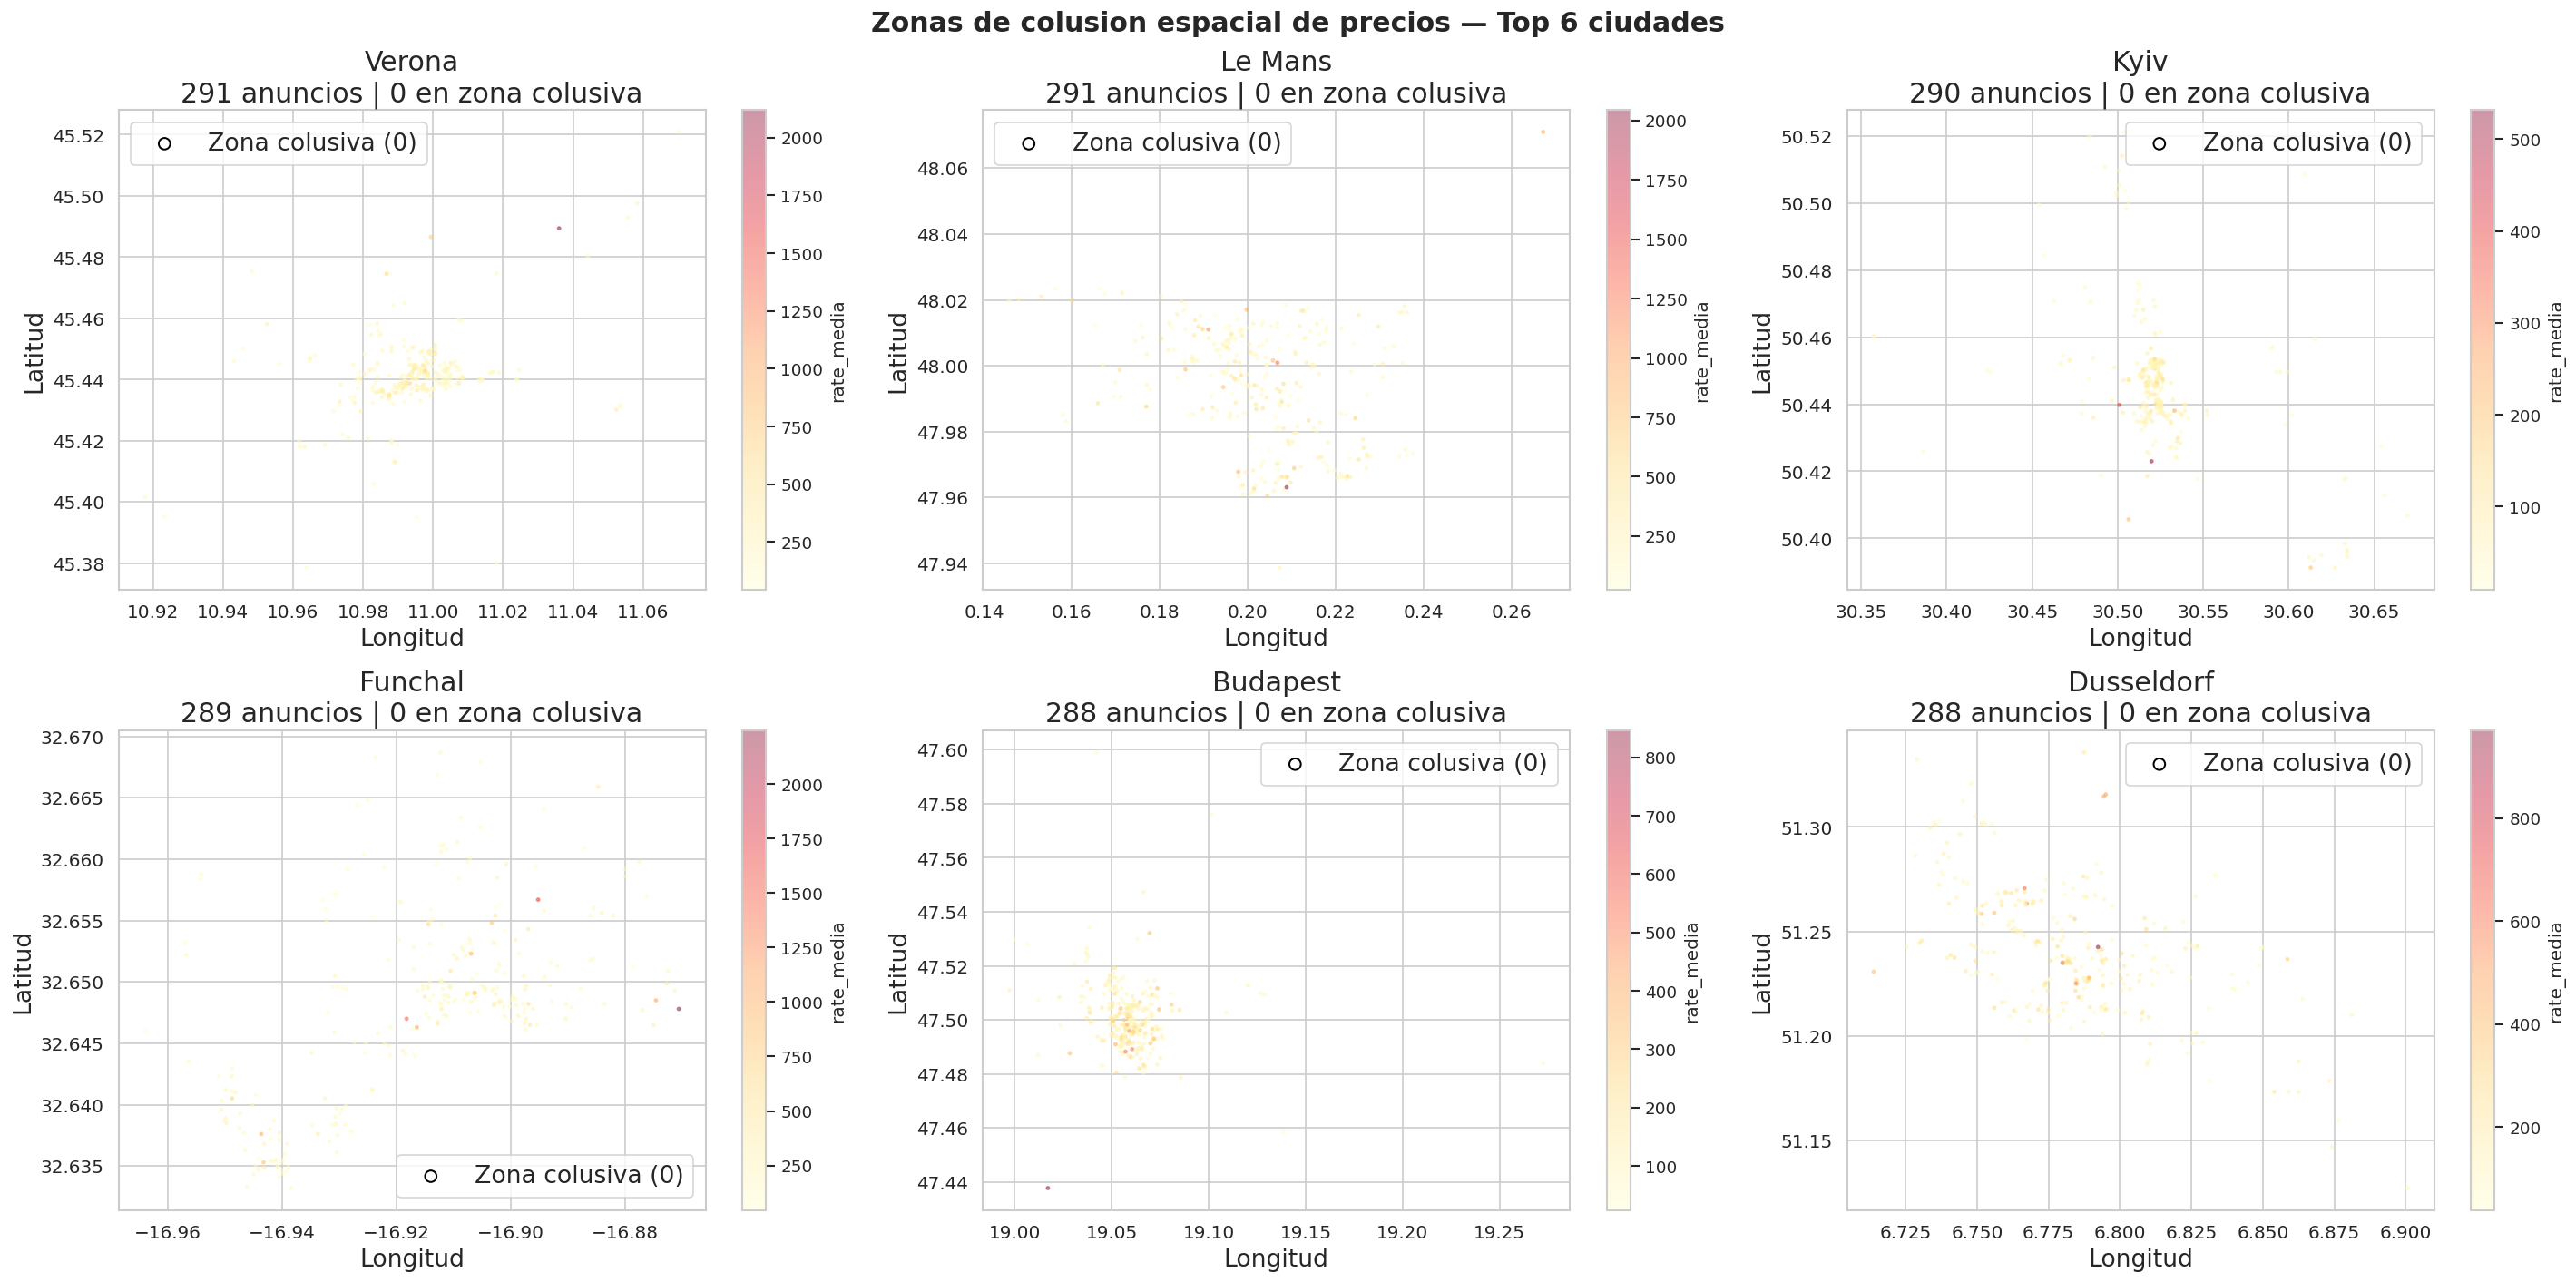

In [37]:
# Mapa: anuncios por ciudad coloreados por precio; en rojo los que pertenecen a zonas colusivas
zonas_colusivas_ids = set(zona_stats_clean.loc[zona_stats_clean['zona_colusiva'] == 1, 'zona'])
df_p4['en_zona_colusiva'] = df_p4['zona'].isin(zonas_colusivas_ids)

top_cities = df_p4['city'].value_counts().head(6).index
fig, axes = plt.subplots(2, 3, figsize=(24, 12))

for ax, city in zip(axes.flat, top_cities):
    sub = df_p4[df_p4['city'] == city]
    sc = ax.scatter(sub['longitude'], sub['latitude'], c=sub['rate_media'],
                    cmap='YlOrRd', s=4, alpha=0.4)
    col = sub[sub['en_zona_colusiva']]
    ax.scatter(col['longitude'], col['latitude'], facecolors='none',
               edgecolors='black', s=40, linewidths=1.2,
               label=f'Zona colusiva ({len(col)})')
    ax.set_title(f"{city}\n{len(sub):,} anuncios | {len(col)} en zona colusiva", fontsize=18)
    ax.set_xlabel('Longitud', fontsize=16); ax.set_ylabel('Latitud', fontsize=16)
    ax.tick_params(labelsize=12)
    plt.colorbar(sc, ax=ax, label='rate_media')
    ax.legend(fontsize=16, markerscale=1.2)

plt.suptitle('Zonas de colusion espacial de precios — Top 6 ciudades',
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

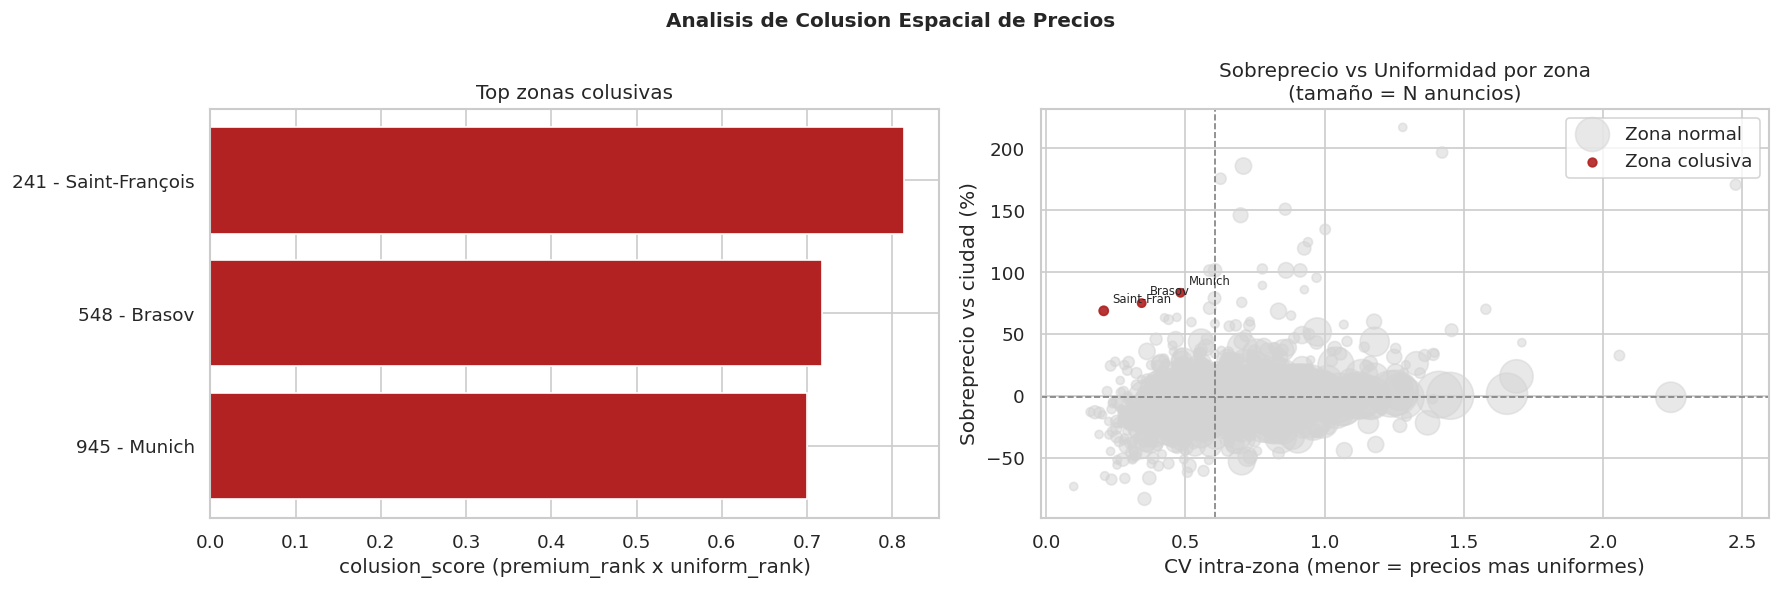

In [38]:
# Diagnostico: sobreprecio vs uniformidad. Las colusivas viven en la esquina sup-izquierda.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Top zonas por colusion_score
top_z = sospechosas[sospechosas['zona_colusiva'] == 1].head(12).iloc[::-1]
axes[0].barh(top_z['zona'].astype(str) + ' - ' + top_z['city'],
             top_z['colusion_score'], color='firebrick')
axes[0].set_xlabel('colusion_score (premium_rank x uniform_rank)')
axes[0].set_title('Top zonas colusivas')

# 2. Sobreprecio vs CV; resaltadas las zonas colusivas
zc = zona_stats_clean
axes[1].scatter(zc['cv_intrazona'], zc['premium_vs_ciudad_pct'],
                c='lightgray', s=zc['n_anuncios'] * 3, alpha=0.5, label='Zona normal')
col = zc[zc['zona_colusiva'] == 1]
axes[1].scatter(col['cv_intrazona'], col['premium_vs_ciudad_pct'],
                c='firebrick', s=col['n_anuncios'] * 3, alpha=0.9, label='Zona colusiva')
axes[1].axhline(zc['premium_vs_ciudad_pct'].median(), color='gray', lw=1, ls='--')
axes[1].axvline(zc['cv_intrazona'].median(), color='gray', lw=1, ls='--')
axes[1].set_xlabel('CV intra-zona (menor = precios mas uniformes)')
axes[1].set_ylabel('Sobreprecio vs ciudad (%)')
axes[1].set_title('Sobreprecio vs Uniformidad por zona\n(tamaño = N anuncios)')
axes[1].legend()
for _, r in col.sort_values('colusion_score', ascending=False).head(5).iterrows():
    axes[1].annotate(f"{r['city'][:10]}", (r['cv_intrazona'], r['premium_vs_ciudad_pct']),
                     fontsize=7, xytext=(5, 5), textcoords='offset points')

plt.suptitle('Analisis de Colusion Espacial de Precios', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
print("=" * 60)
print("RESPUESTA P4 - Colusion Espacial de Precios")
print("=" * 60)

colusivas = zona_stats_clean[zona_stats_clean['zona_colusiva'] == 1].sort_values(
    'colusion_score', ascending=False)

print(f"\nZonas colusivas detectadas: {len(colusivas)} de {len(zona_stats_clean):,} "
      f"zonas validas ({len(colusivas)/len(zona_stats_clean)*100:.1f}%)")
print("Cada una combina: sobreprecio + precios uniformes + varios hosts + coordinacion temporal de precios.\n")

print(f"  Sobreprecio mediano (colusivas) : {colusivas['premium_vs_ciudad_pct'].median():.0f}%")
print(f"  CV mediano (colusivas)          : {colusivas['cv_intrazona'].median():.3f}")
print(f"  sync_resid mediano (colusivas)  : {colusivas['sync_resid'].median():.3f}")
print(f"  sync_resid mediano (resto)      : "
      f"{zona_stats_clean.loc[zona_stats_clean['zona_colusiva']==0,'sync_resid'].median():.3f}")

cols_show = ['city', 'n_anuncios', 'n_hosts', 'frac_top_host', 'rate_zona_avg',
             'premium_vs_ciudad_pct', 'cv_intrazona', 'sync_resid', 'colusion_score']
print("\nZonas candidatas a investigar (ordenadas por riesgo):")
display(colusivas[cols_show].round(3))

# Diagnostico detallado de las 3 de mayor riesgo
for _, row in colusivas.head(3).iterrows():
    zona_id = row['zona']
    print(f"\n{'='*50}")
    print(f"Zona {int(zona_id)} - {row['city']}")
    print(f"  Precio promedio ciudad : ${row['city_rate_avg']:.0f}")
    print(f"  Precio promedio zona   : ${row['rate_zona_avg']:.0f}  (+{row['premium_vs_ciudad_pct']:.0f}%)")
    print(f"  CV intra-zona          : {row['cv_intrazona']:.3f}  |  hosts distintos: {int(row['n_hosts'])}")
    print(f"  Co-movimiento temporal : {row['sync_resid']:.3f}")
    anuncios_zona = df_p4[df_p4['zona'] == zona_id]
    display(anuncios_zona[['host_id', 'rate_media']].sort_values('rate_media'))

RESPUESTA P4 - Colusion Espacial de Precios

Zonas colusivas detectadas: 3 de 935 zonas validas (0.3%)
Cada una combina: sobreprecio + precios uniformes + varios hosts + coordinacion temporal de precios.

  Sobreprecio mediano (colusivas) : 75%
  CV mediano (colusivas)          : 0.343
  sync_resid mediano (colusivas)  : 0.236
  sync_resid mediano (resto)      : 0.095

Zonas candidatas a investigar (ordenadas por riesgo):


,city,n_anuncios,n_hosts,frac_top_host,rate_zona_avg,premium_vs_ciudad_pct,cv_intrazona,sync_resid,colusion_score
141,Saint-François,10,8,0.300,264.726,68.734,0.207,0.236,0.814
357,Brasov,8,7,0.250,164.694,74.934,0.343,0.214,0.717
601,Munich,8,8,0.125,280.505,83.301,0.483,0.527,0.700



Zona 241 - Saint-François
  Precio promedio ciudad : $157
  Precio promedio zona   : $265  (+69%)
  CV intra-zona          : 0.207  |  hosts distintos: 8
  Co-movimiento temporal : 0.236


,host_id,rate_media
13131,ca7b1b9eec17,175.158333
13147,4f390601d4d9,177.716667
13132,ca7b1b9eec17,217.908333
13341,da8736f98d06,277.175000
13277,ca7b1b9eec17,282.200000
13126,8eba0f45b932,288.208333
13299,7e492975bd9e,294.000000
13143,2d3ea070d535,294.591667
13215,b5ef9269a65b,307.150000
13217,1dedd04127f6,333.150000



Zona 548 - Brasov
  Precio promedio ciudad : $94
  Precio promedio zona   : $165  (+75%)
  CV intra-zona          : 0.343  |  hosts distintos: 7
  Co-movimiento temporal : 0.214


,host_id,rate_media
29252,d552eec8f3c1,94.741667
29184,2a5be8e89a67,115.033333
29218,d552eec8f3c1,117.575000
29175,8bd7c1970534,124.750000
29255,dd731cdb5a7f,198.950000
29183,02f1010644d4,213.775000
29201,ff71aa6fcae0,225.608333
29196,4b207169b572,227.116667



Zona 945 - Munich
  Precio promedio ciudad : $153
  Precio promedio zona   : $281  (+83%)
  CV intra-zona          : 0.483  |  hosts distintos: 8
  Co-movimiento temporal : 0.527


,host_id,rate_media
52551,0b7dfa4bdec1,108.100000
52599,9b32a8818ce0,159.975000
52623,4737958a06fc,173.225000
52516,5186545bc6b2,240.900000
52605,7b134e898154,299.200000
52680,2ee95fda0e12,376.166667
52545,d8c5ae24c9a9,378.158333
52403,bdf4ad9e61df,508.316667


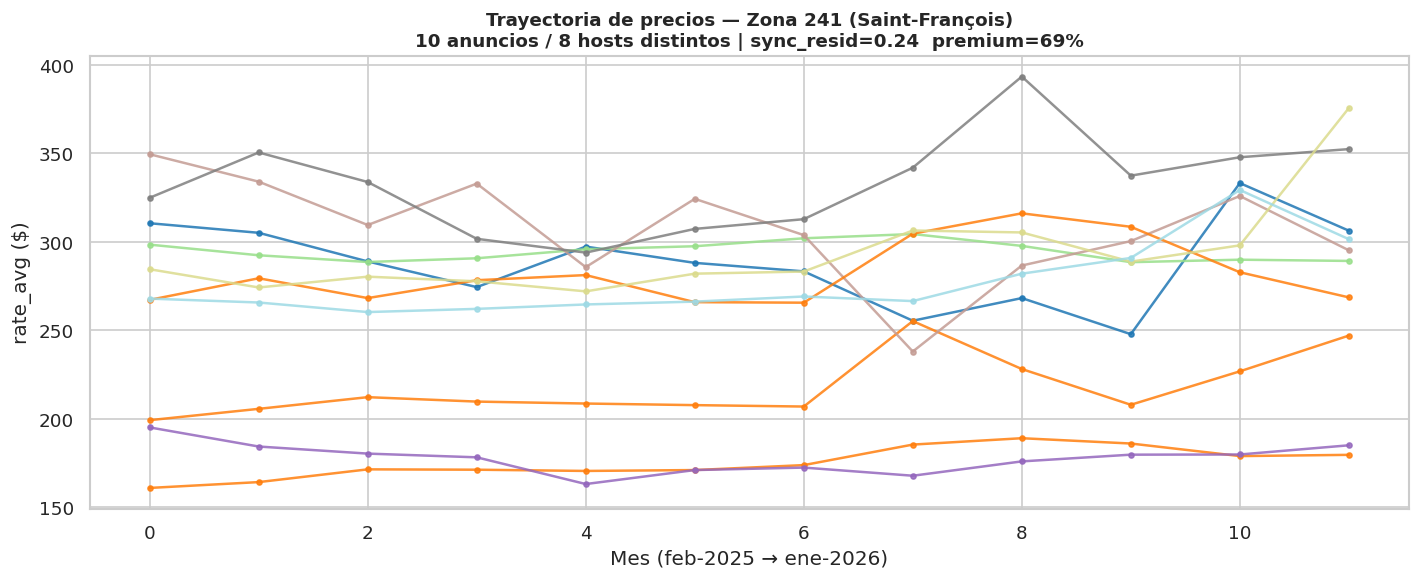

In [40]:
# Visual: trayectorias de precio de la zona colusiva de mayor riesgo (cada linea = anuncio, color = host)
top = colusivas.iloc[0] if len(colusivas) else sospechosas.iloc[0]
zid, zcity = top['zona'], top['city']
ids_z = [i for i in df_p4.loc[df_p4['zona'] == zid, 'listing_id'] if i in rates_mes.index]
serie = rates_mes.loc[ids_z]
host_of = df_p4.set_index('listing_id').loc[ids_z, 'host_id']
host_color = {h: c for h, c in zip(host_of.unique(),
              plt.cm.tab20(np.linspace(0, 1, host_of.nunique())))}

fig, ax = plt.subplots(figsize=(12, 5))
for lid in ids_z:
    ax.plot(range(serie.shape[1]), serie.loc[lid].values, marker='o', ms=3,
            alpha=0.85, color=host_color[host_of.loc[lid]])
ax.set_title(f"Trayectoria de precios — Zona {int(zid)} ({zcity})\n"
             f"{len(ids_z)} anuncios / {host_of.nunique()} hosts distintos | "
             f"sync_resid={top['sync_resid']:.2f}  premium={top['premium_vs_ciudad_pct']:.0f}%",
             fontsize=11, fontweight='bold')
ax.set_xlabel('Mes (feb-2025 → ene-2026)'); ax.set_ylabel('rate_avg ($)')
plt.tight_layout(); plt.show()

**Lectura final.** Al exigir las cuatro condiciones a la vez, el criterio deja de estar dominado por balnearios: sobreviven solo las zonas que, además de caras y uniformes, muestran **anfitriones independientes moviendo precios al unísono por encima del mercado**. La verificación de ortogonalidad (corr ≈ 0 entre `sync_resid` y el sobreprecio / CV) confirma que la sincronía temporal aporta información que las señales estáticas no contenían y el gráfico de trayectorias permite inspeccionar visualmente el *lockstep* de la zona de mayor riesgo.

Sigue siendo un método de **señalización de candidatas, no de prueba**: la sincronía también puede provenir de hosts que comparten la misma herramienta de *revenue management* sin acuerdo explícito (colusión algorítmica tácita). Pero, a diferencia de un simple ranking de precios altos, separa de forma defendible "ubicación legítimamente cara" de "precios que se coordinan en el tiempo".